In [1]:
# Librairies
import os
import sys
import pandas as pd
import numpy as np

# Add path of HydromodPY
#sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/CORE_COMM/src')

user_path="Alexandre" #Jean-Raynald or Ronan


if user_path=="Alexandre":
    sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
elif user_path=="Jean-Raynald":
    sys.path.append('C:/DATA/codes-gitlab-public/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
elif user_path=="Ronan":
    sys.path.append('C:/.../HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
else:
    print("Define a well-validated name of user")

# Modules
import watershed

In [2]:
load=True
'''
watershed_name = 'Barneville-Carteret'
x_outlet = 352300
y_outlet = 6929662
watershed_name = 'Baie-du-cotentin'
x_outlet = 399382
y_outlet = 6929848
watershed_name = 'Saint-Germain-sur-Ay'
x_outlet = 364188
y_outlet = 6913437'''
watershed_name = 'Agon-Coutainville'
x_outlet = 363669
y_outlet = 6894593
snap_dist = 100

if user_path=="Alexandre":
    root_path= "C:/Users/alexa/Dropbox/HydroModPy/_data/"
    out_path = 'C:/Users/alexa/Dropbox/HydroModPy'
elif user_path=="Jean-Raynald":
    root_path= "C:/DATA/codes-gitlab-public/HydroModPy_data/"
    out_path = "C:/DATA/results/HydroModPy"
elif user_path=="Ronan":
    root_path= ""
    out_path = ""
else:
    print("Define a well-validated name of user")

dem_path = root_path + "MNT_TOPO_BATH_75m_corr.tif"
surfex_path =  root_path + 'SURFEX/Normandie_h5'
geology_path = root_path + 'GEOLOGY'
oceanic_path = root_path + 'OCEAN'
modflow_path = root_path + 'MODFLOW'
hydrology_path = root_path + 'HYDROLOGY'
BV = watershed.build(watershed_name=watershed_name, dem_path=dem_path, 
                     x_outlet=x_outlet, y_outlet=y_outlet, snap_dist=snap_dist, 
                     buff_dist=2000, out_path=out_path,surfex_path=surfex_path, 
                     geology_path = geology_path, hydrology_path=hydrology_path, oceanic_path=oceanic_path, modflow_path=modflow_path , load=load)

if load == False:
    BV.add_piezometry_data()
    BV.save_object()

In [7]:
import calib_strategy as cs
strats = cs.CalibStrategies(BV)

In [12]:
strats.strategies.drop([0])

,observed_data,homogenous_heterogenous,state
1,piezometry,homogeneous,steady
2,streams,heterogeneous,transient
3,piezometry,heterogeneous,transient


In [6]:
import calib_params as cp
params = cp.CalibParams(BV.results_folder, BV.geology.geology_code)

,observed_data,homogenous_heterogenous,params
0,streams,homogeneous,k_e
1,piezometry,homogeneous,k_e
2,streams,heterogeneous,k_e_theta
3,piezometry,heterogeneous,k_e_theta


In [18]:
len([x for x in params.names if x.startswith('k')])

3

<AxesSubplot:xlabel='Date'>

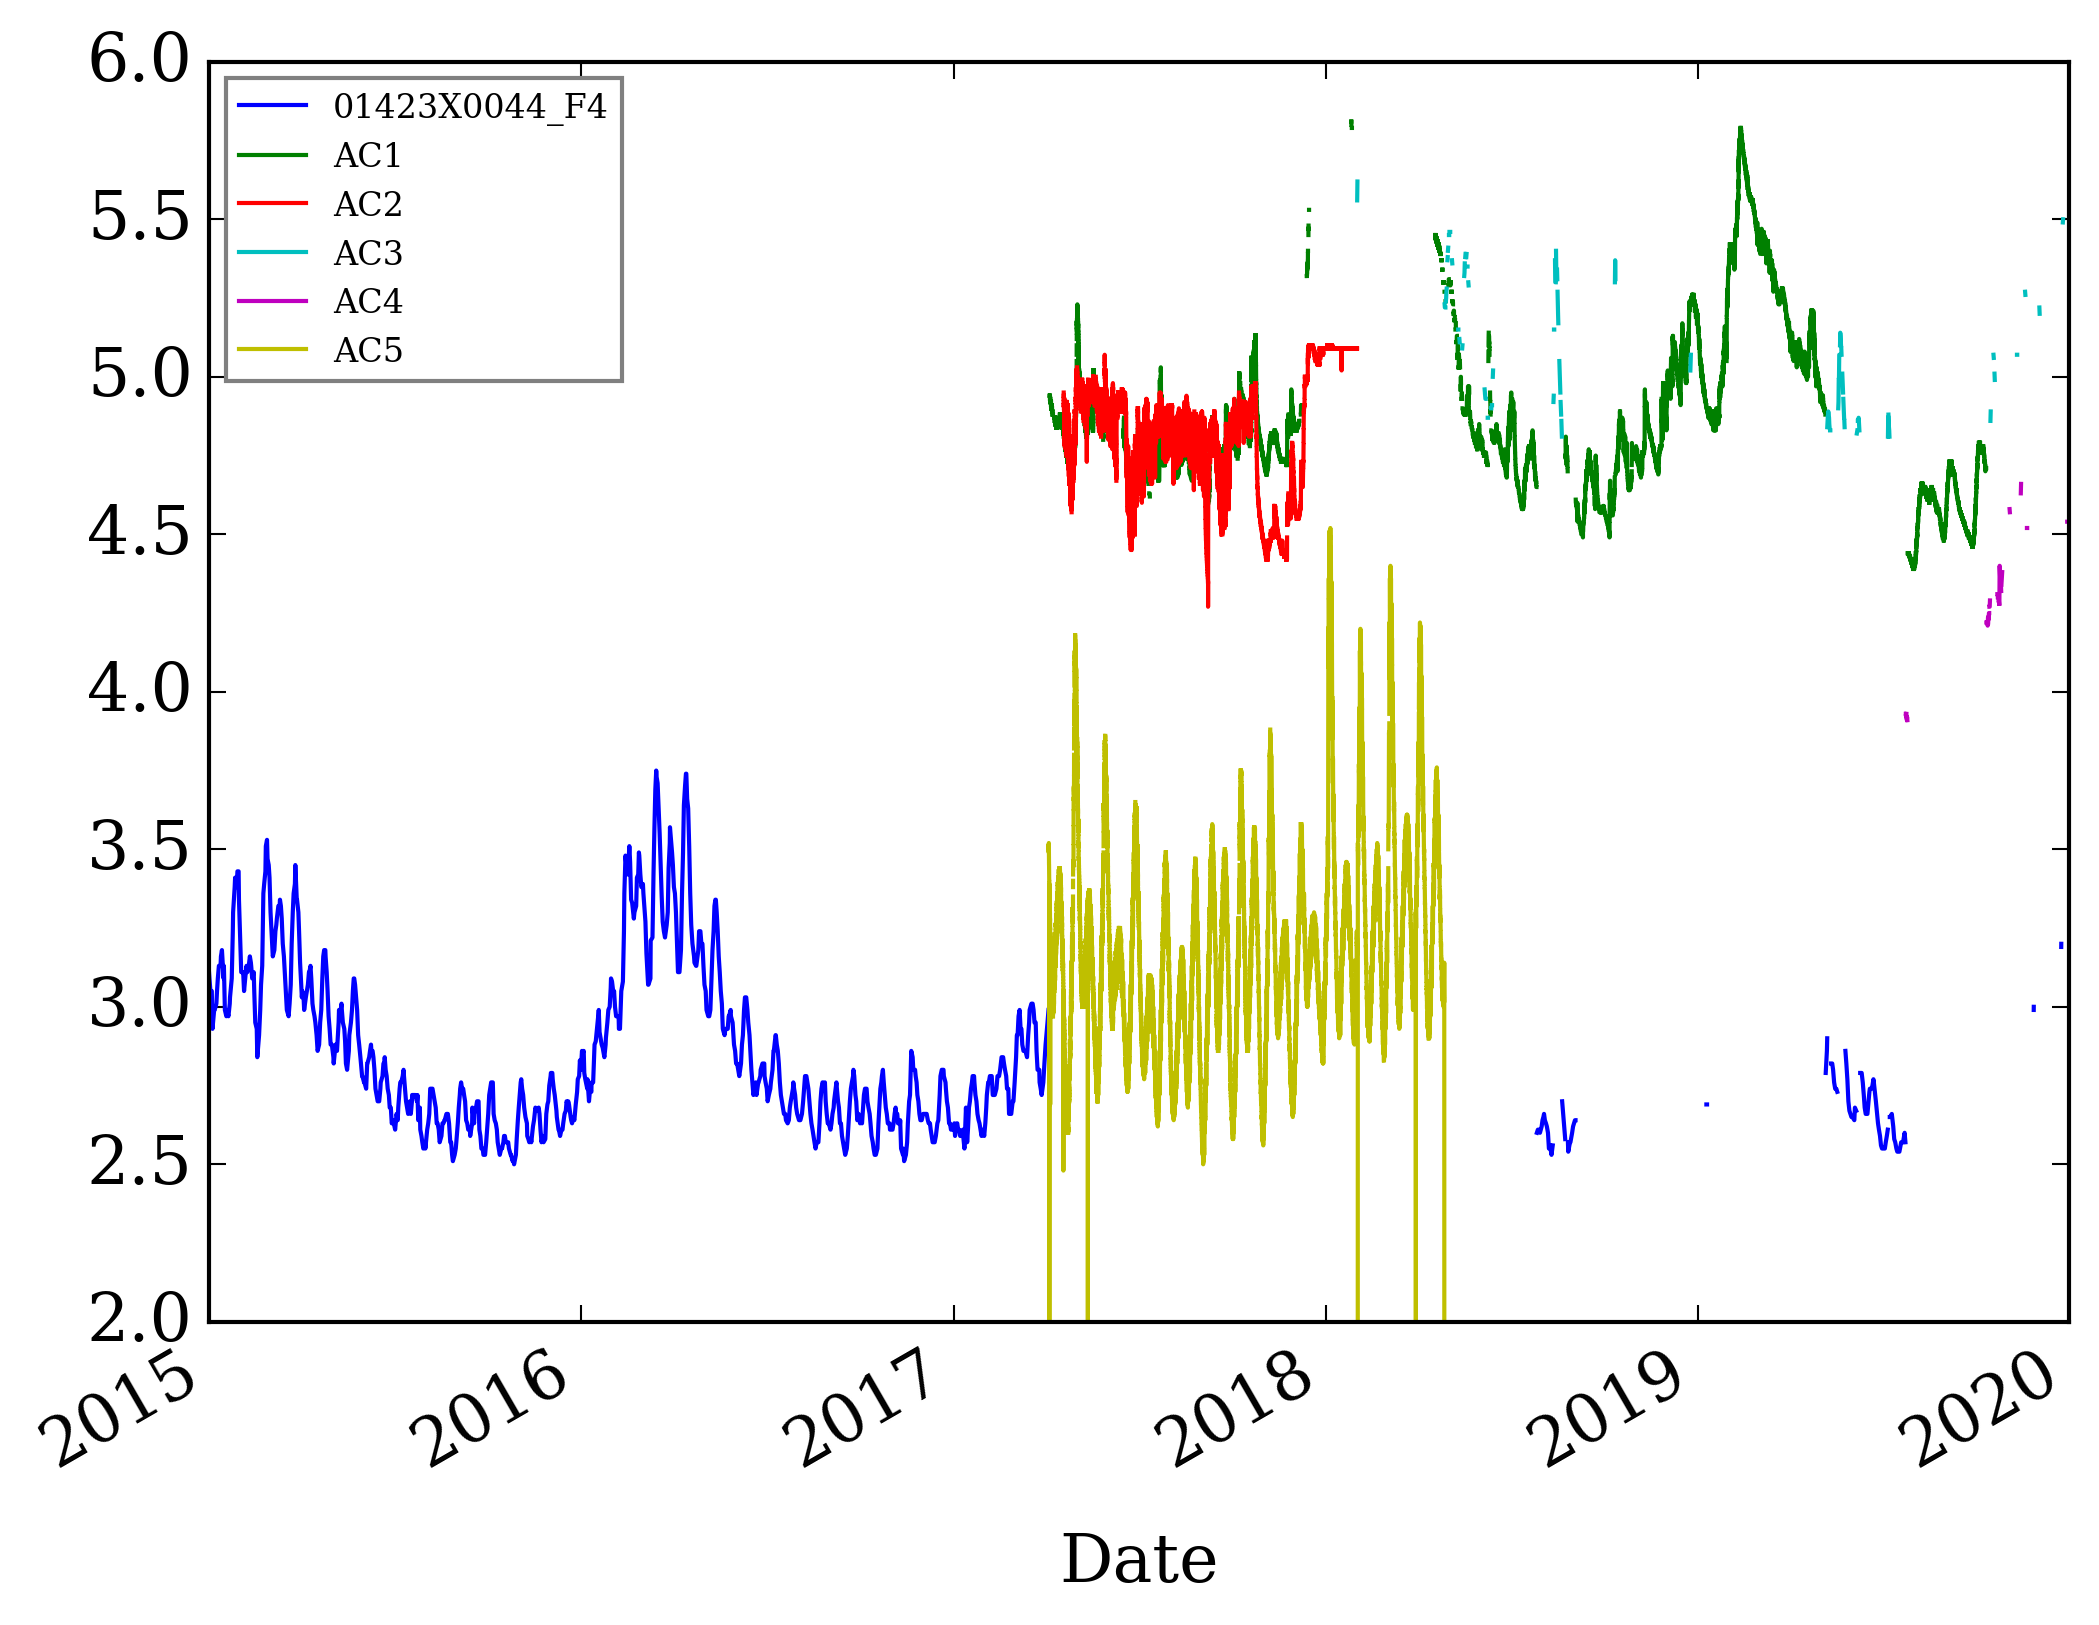

In [ ]:
BV.piezometry.elevation.plot(ylim=(2,6), xlim=('2015','2020'))

[0.864 0.864 0.864]
[-5. -5. -5.]
     code  obs_to_sim  sim_to_obs  ratio_dist     log10
0     1.0    7.077963  401.701027   56.753763  3.076497
1  2101.0    8.970880  267.301646   29.796592  2.173167
2  2121.0   13.774246  764.461377   55.499326  3.042540
8.292204023040073
[0.4858629 0.864     0.864    ]
[-5.25 -5.   -5.  ]
     code  obs_to_sim  sim_to_obs  ratio_dist     log10
0     1.0    1.000000  446.862107  446.862107  7.023420
1  2101.0    8.970880  269.162745   30.004052  2.182060
2  2121.0   13.774246  761.733233   55.301265  3.037125
12.242605721312136
[0.864     0.4858629 0.864    ]
[-5.   -5.25 -5.  ]
     code  obs_to_sim  sim_to_obs  ratio_dist     log10
0     1.0    7.077963  400.796131   56.625916  3.073062
1  2101.0    7.400812  356.190775   48.128611  2.830481
2  2121.0   13.774246  776.237795   56.354285  3.065745
8.969288527295667
[0.864     0.864     0.4858629]
[-5.   -5.   -5.25]
     code  obs_to_sim  sim_to_obs  ratio_dist     log10
0     1.0    7.077963  401.

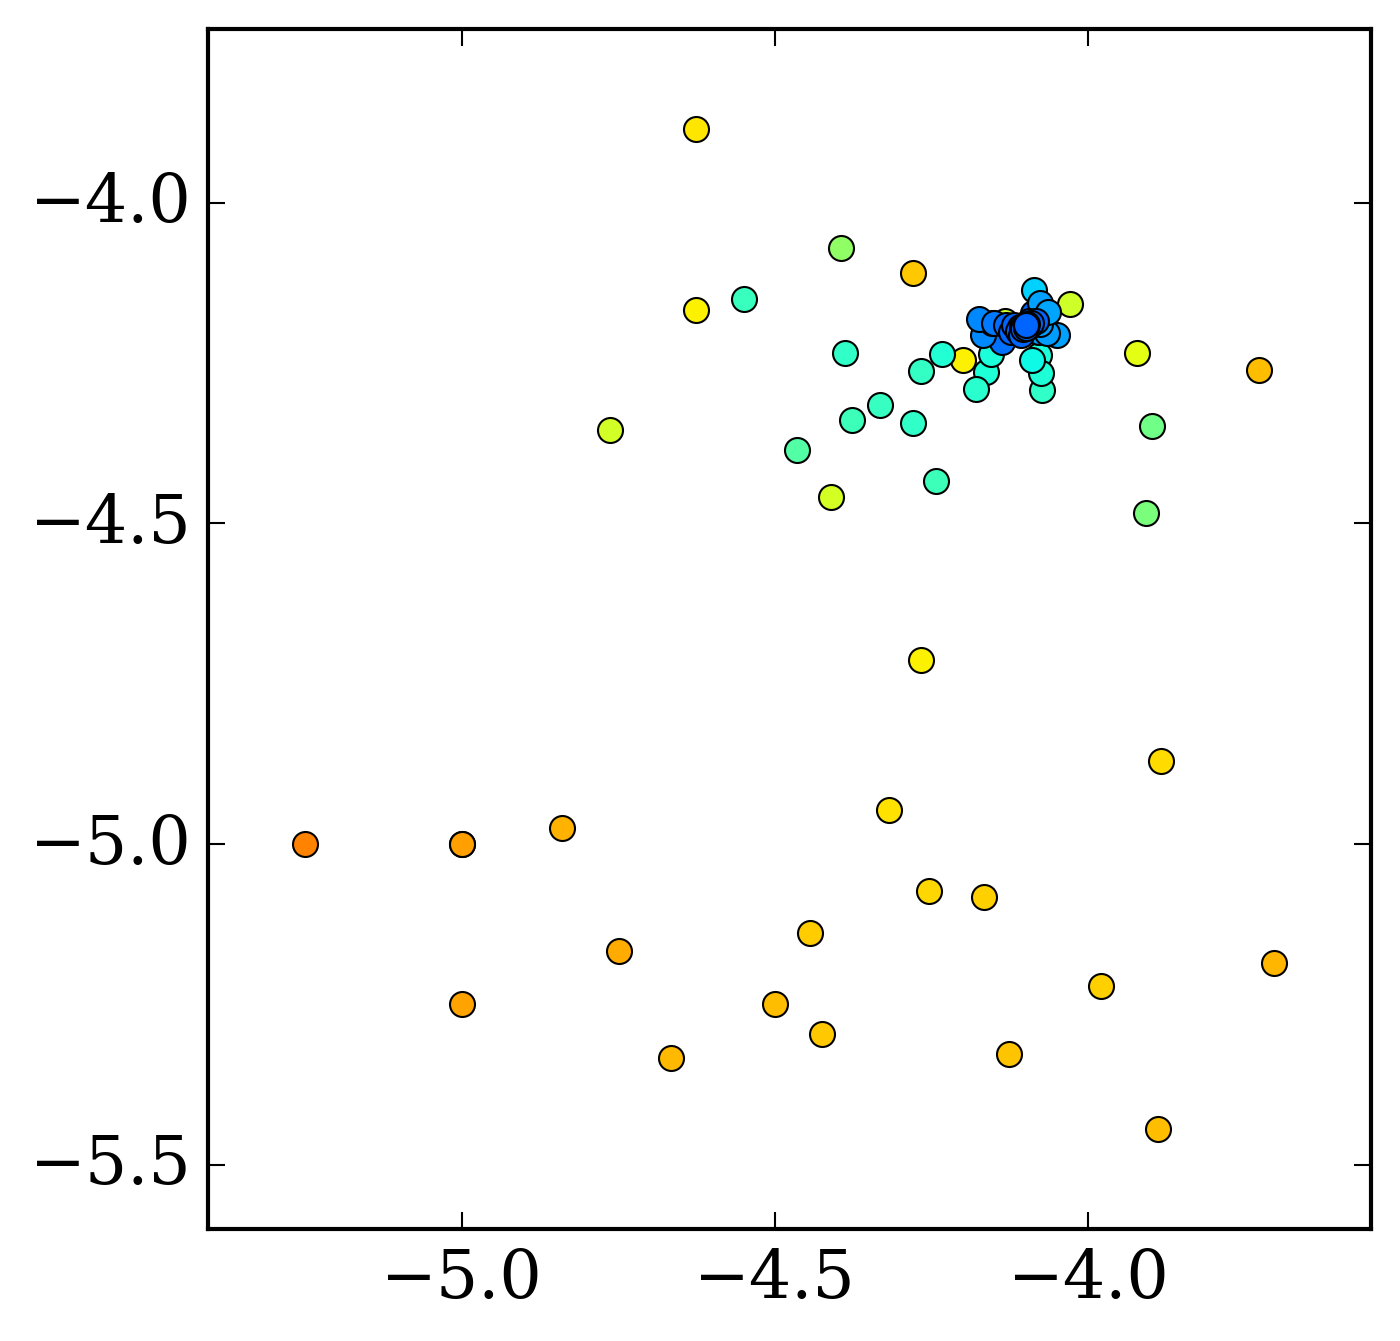

In [4]:
climatic = BV.climatic.values['REA']['REC']['historic']['MEAN'].mean()/1000
BV.run_calibration(BV.geographic, BV.geology, climatic=climatic, type_obs='streams',
		type_mod='het', first=1, last=10000, gap=100, compt=0, watershed='name', 
		lay_number=1, thick=20, porosity=0.01, sea_level=BV.oceanic.MSL)

In [6]:
BV.save_object()

In [11]:
#Transient simulation
start_date = BV.piezometry.elevation.index[0].year
end_date = BV.piezometry.elevation.index[-1].year
end_date = 2021
climatic = BV.climatic.values['REA']['REC']['historic'].loc[str(start_date):str(end_date)]['MEAN'].resample('3M').sum()/1000
name = 'test_transient'
sea_level = BV.oceanic.MSL
hyd_cond = BV.stream_het_calibration.hyd_cond
BV.run_modflow(name,climatic=climatic, lay_number=1, thick=20, bottom=None, thick_exp=1., 
		hyd_cond=hyd_cond, porosity=0.2, sea_level = sea_level, cond_decay=0.)

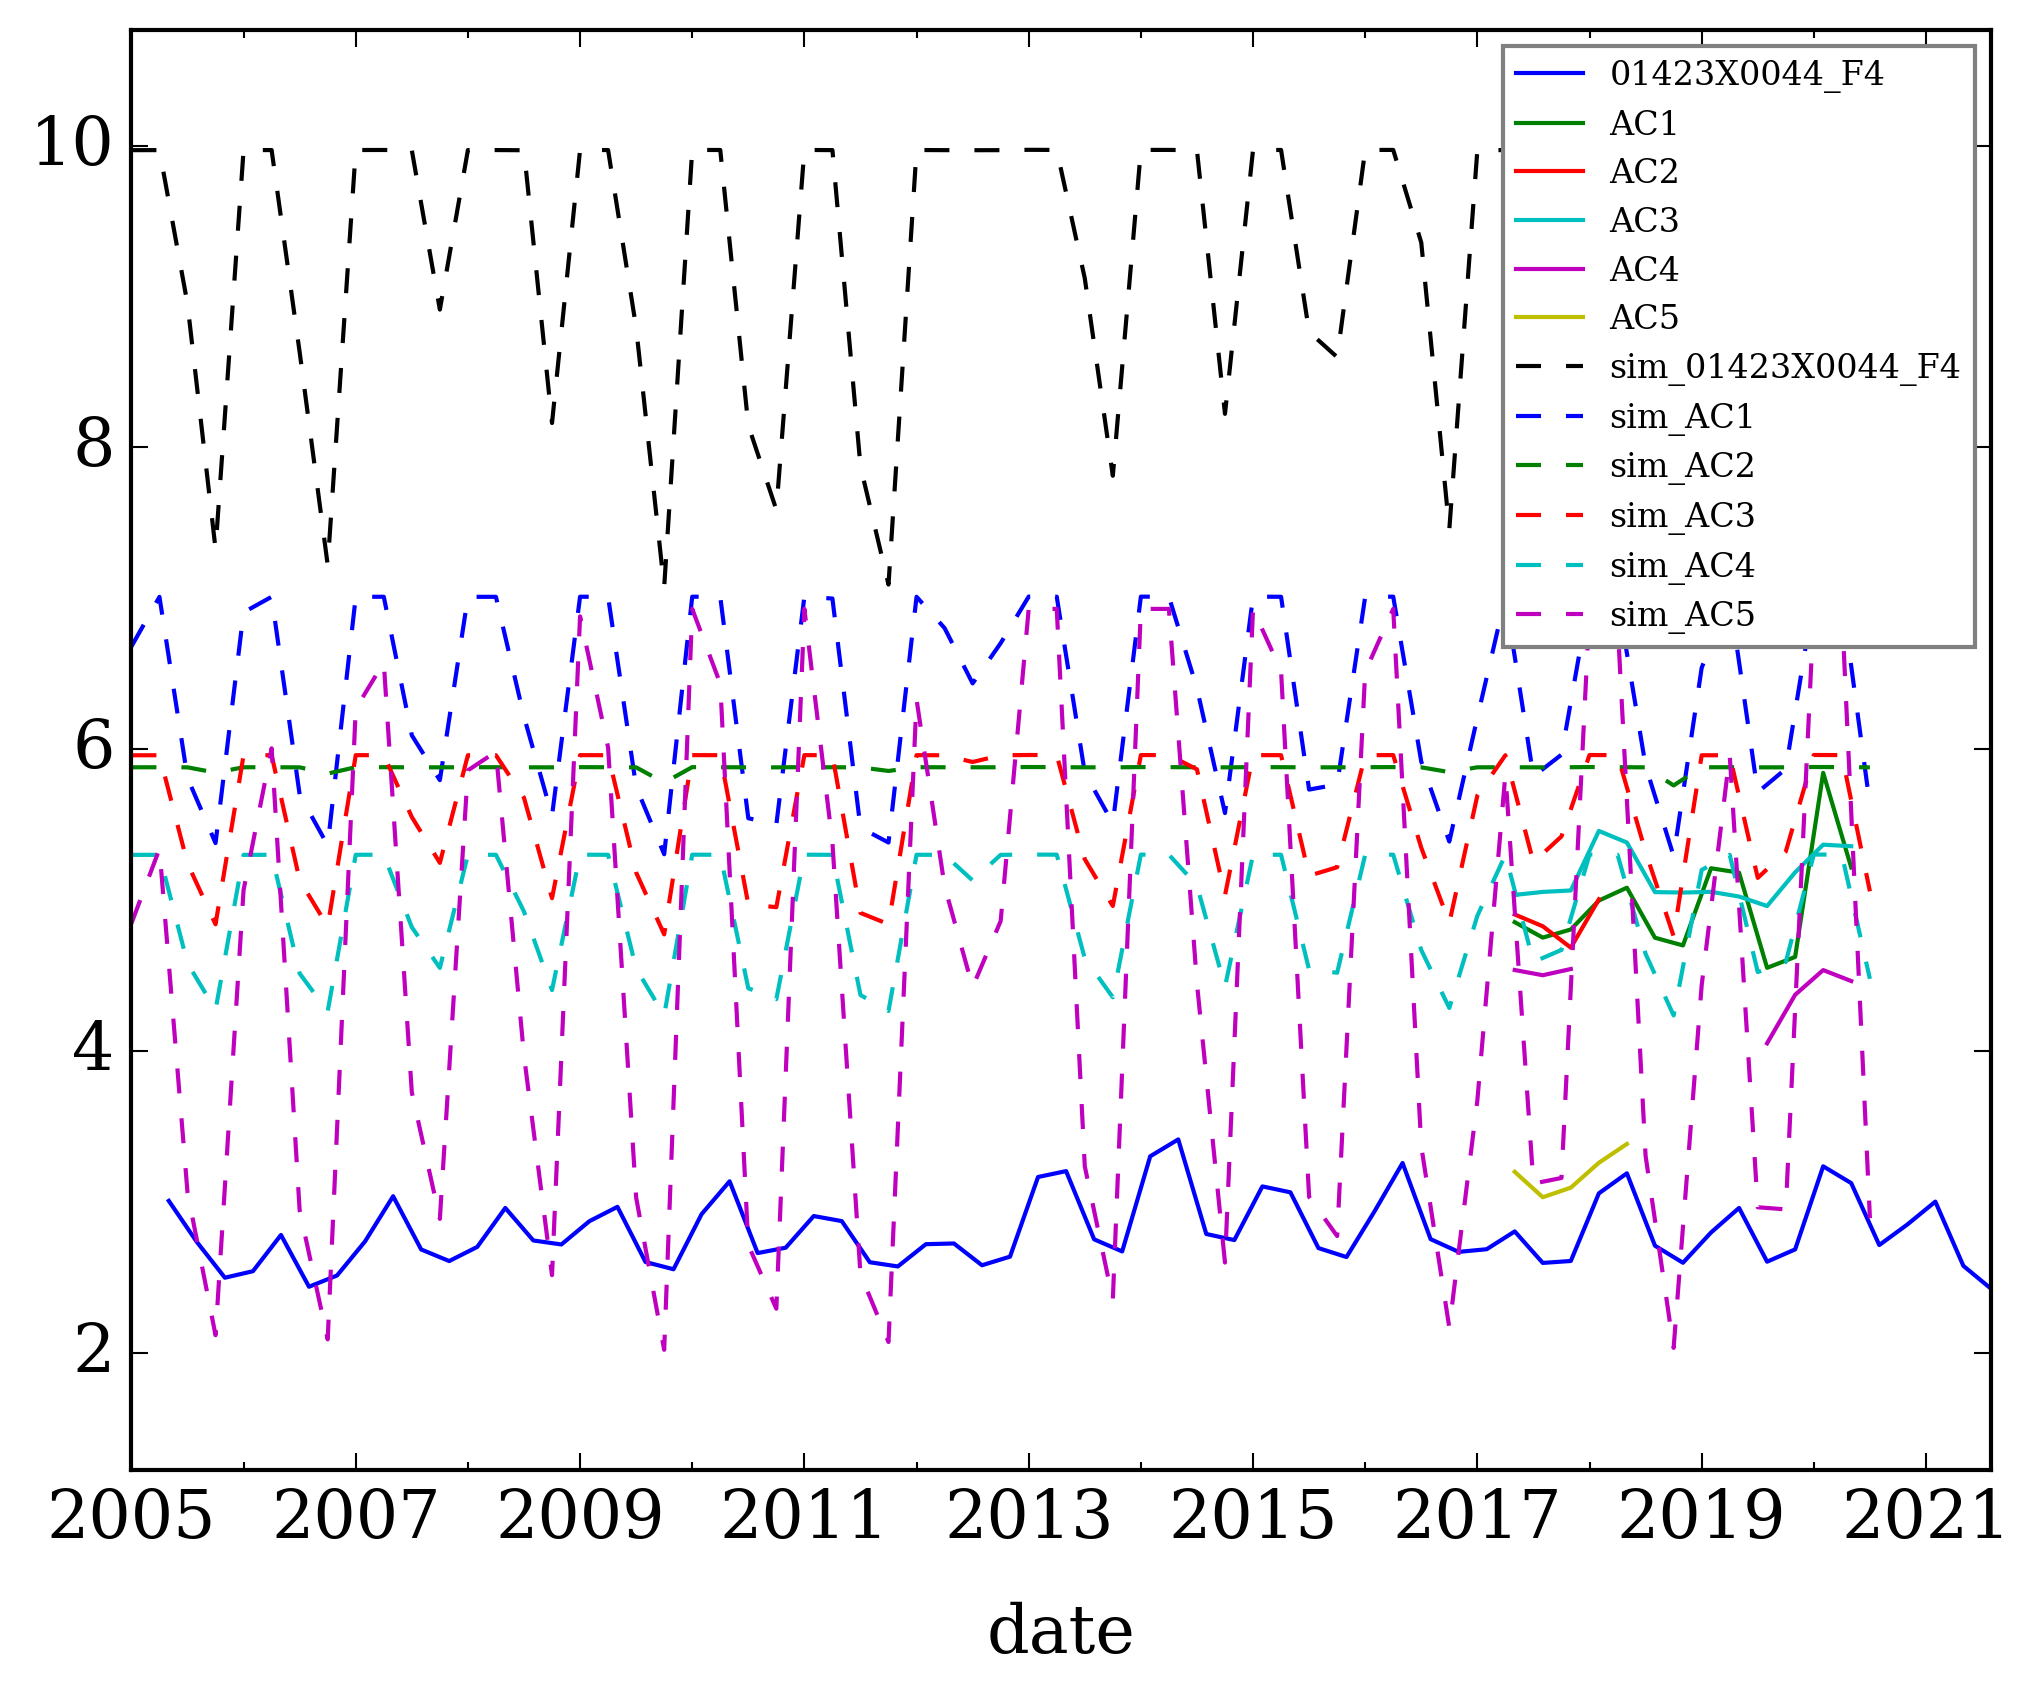

In [12]:
from datetime import timedelta
import pandas as pd
import flopy.utils as fu

ax = BV.piezometry.elevation.resample('3M').mean().plot(xlim=('2005','2021'))
for i in range(0, len(BV.piezometry.y_iloc)):
    date = pd.DataFrame(BV.modflow_models['test_transient'].head_fpu.get_ts((0,BV.piezometry.y_iloc[i],BV.piezometry.x_iloc[i])), columns=['date','sim_'+BV.piezometry.codes_bss[i]])
    date['date'] = fu.totim_to_datetime(BV.modflow_models['test_transient'].head_fpu.get_ts((0,30,28))[:,0],start=climatic.index[0])
    date = date.set_index('date')
    date.plot(style='--',ax=ax)

In [ ]:
# Simulation
Mod = 'IPS1'
RCP = ['RCP2.6','RCP8.5']
Date = [2030,2050,2100]
for sce in RCP:
    print(sce)
    for d in Date:
        name = sce + '_'+str(d)
        print(d)
        climatic = BV.climatic.values['IPS1']['REC'][sce].loc[str(d-5):str(d+5)]['MEAN'].mean()/1000
        print('Recharge = '+str(climatic))
        sea_level = BV.oceanic.RMSL[sce].loc[str(d)]['median'].max()
        print('Sea level = '+str(sea_level))
        BV.run_modflow(name,climatic=climatic, lay_number=1, thick=20, bottom=None, thick_exp=1., 
		hyd_cond=hyd_cond, porosity=0.01, sea_level = sea_level, cond_decay=0.)

<AxesSubplot:xlabel='Date'>

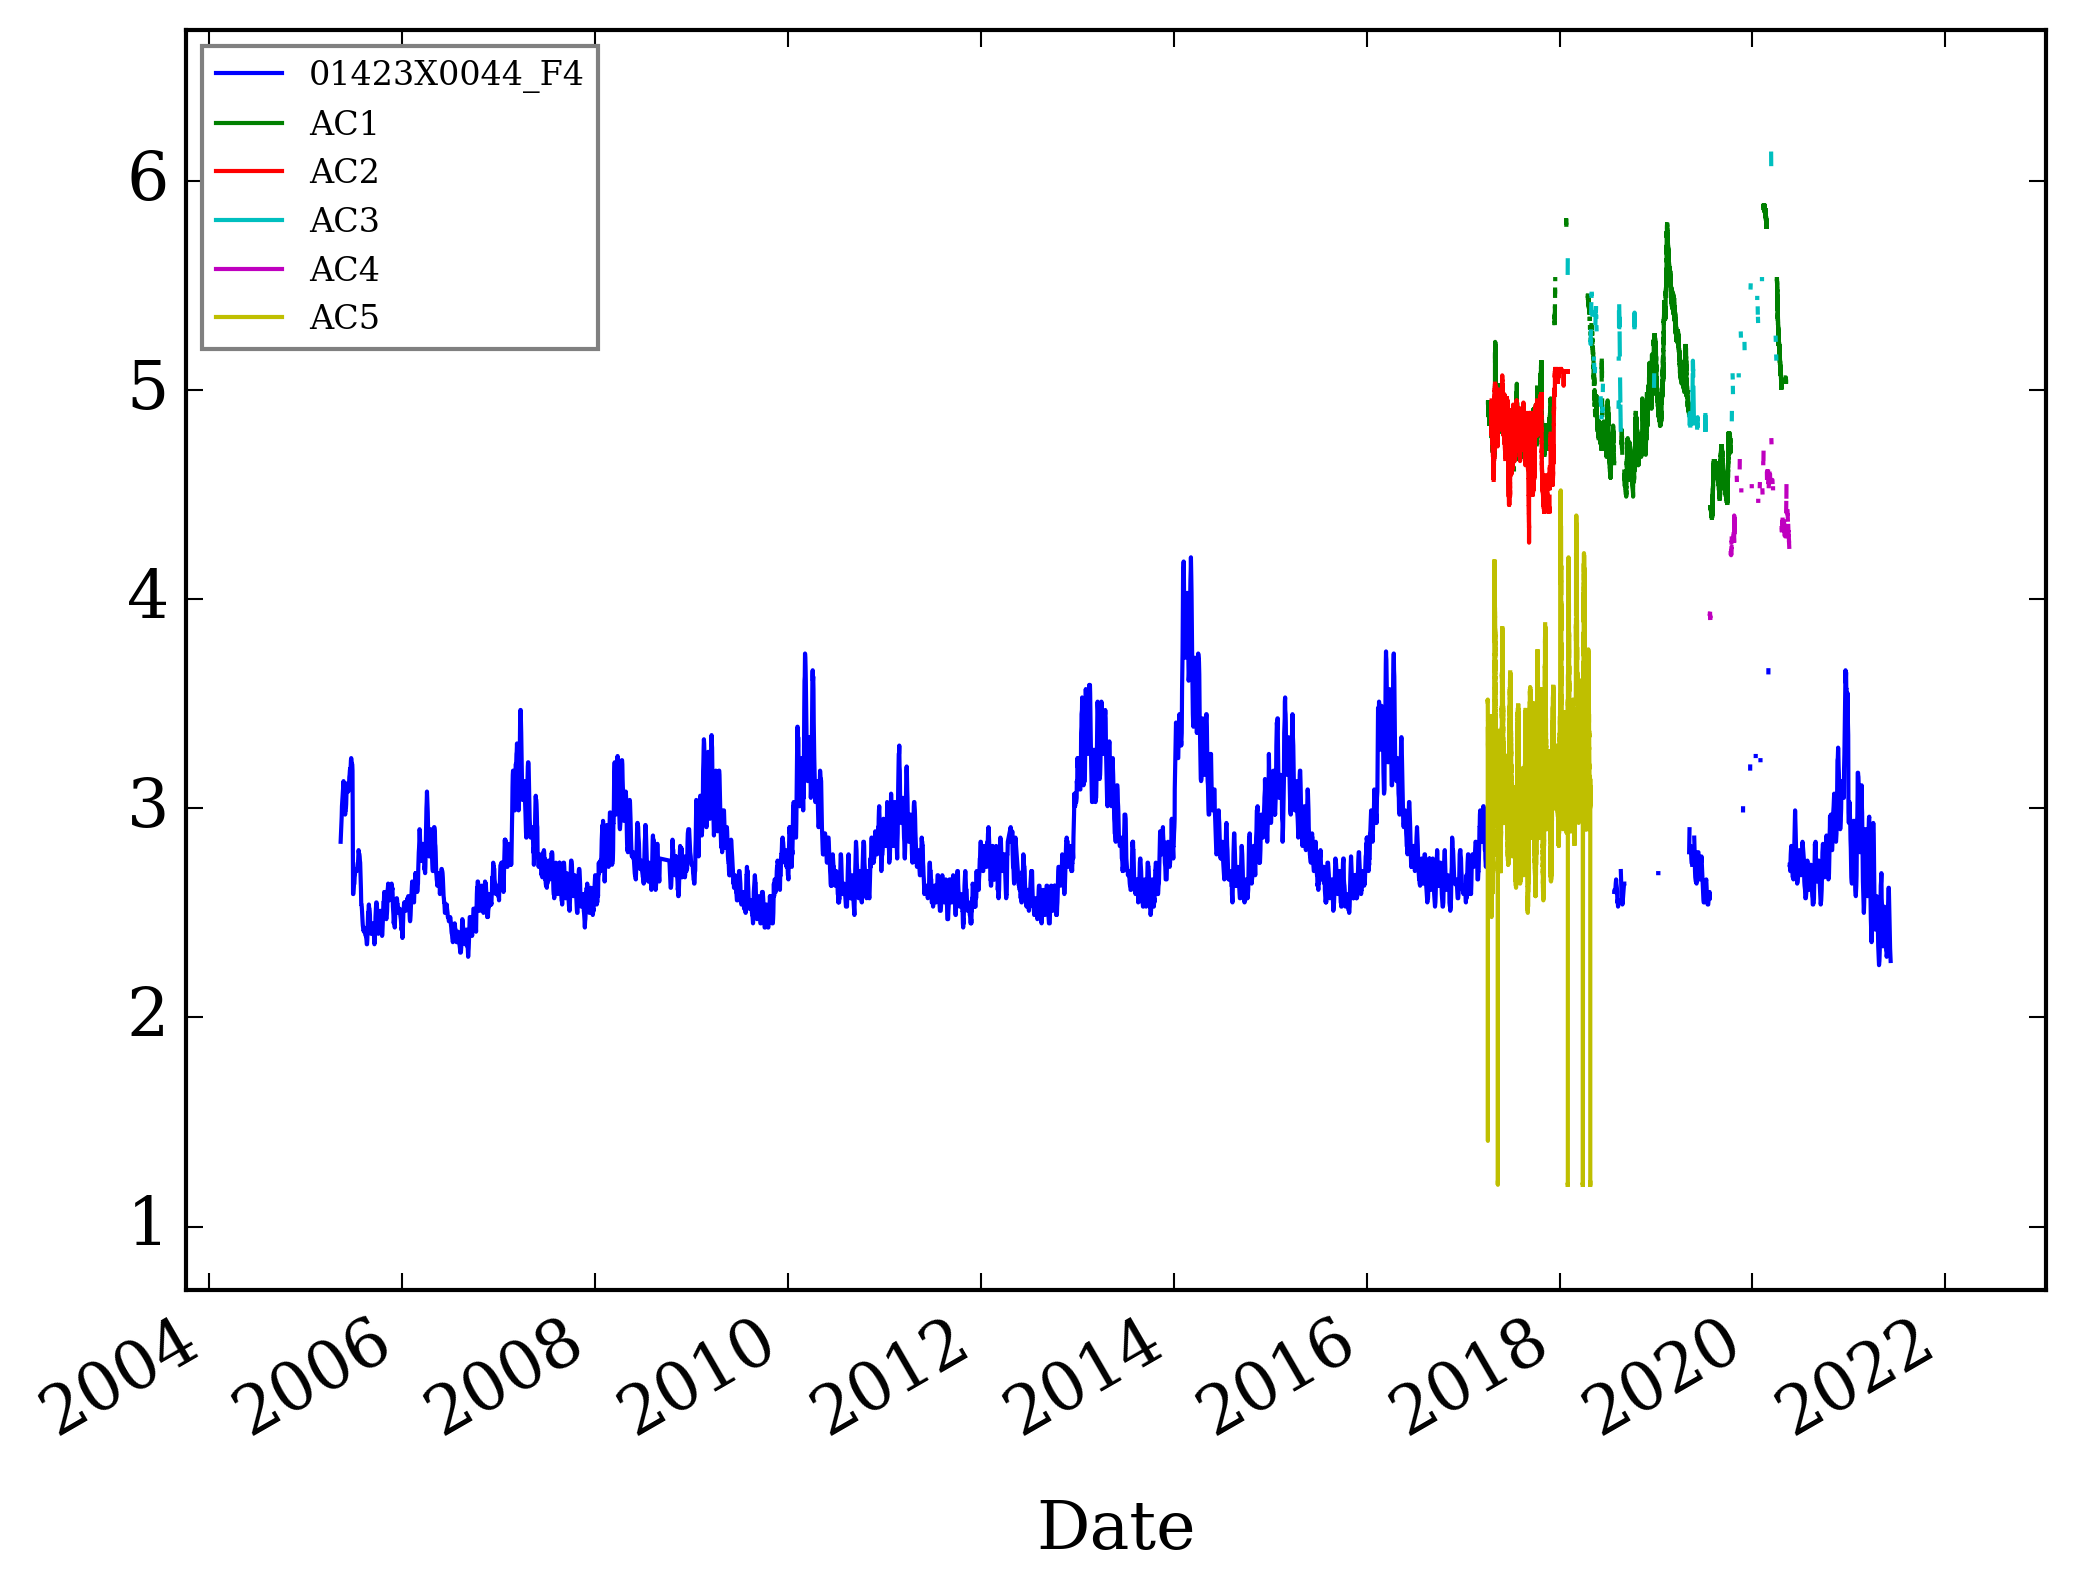

In [16]:
BV.piezometry.elevation.plot()

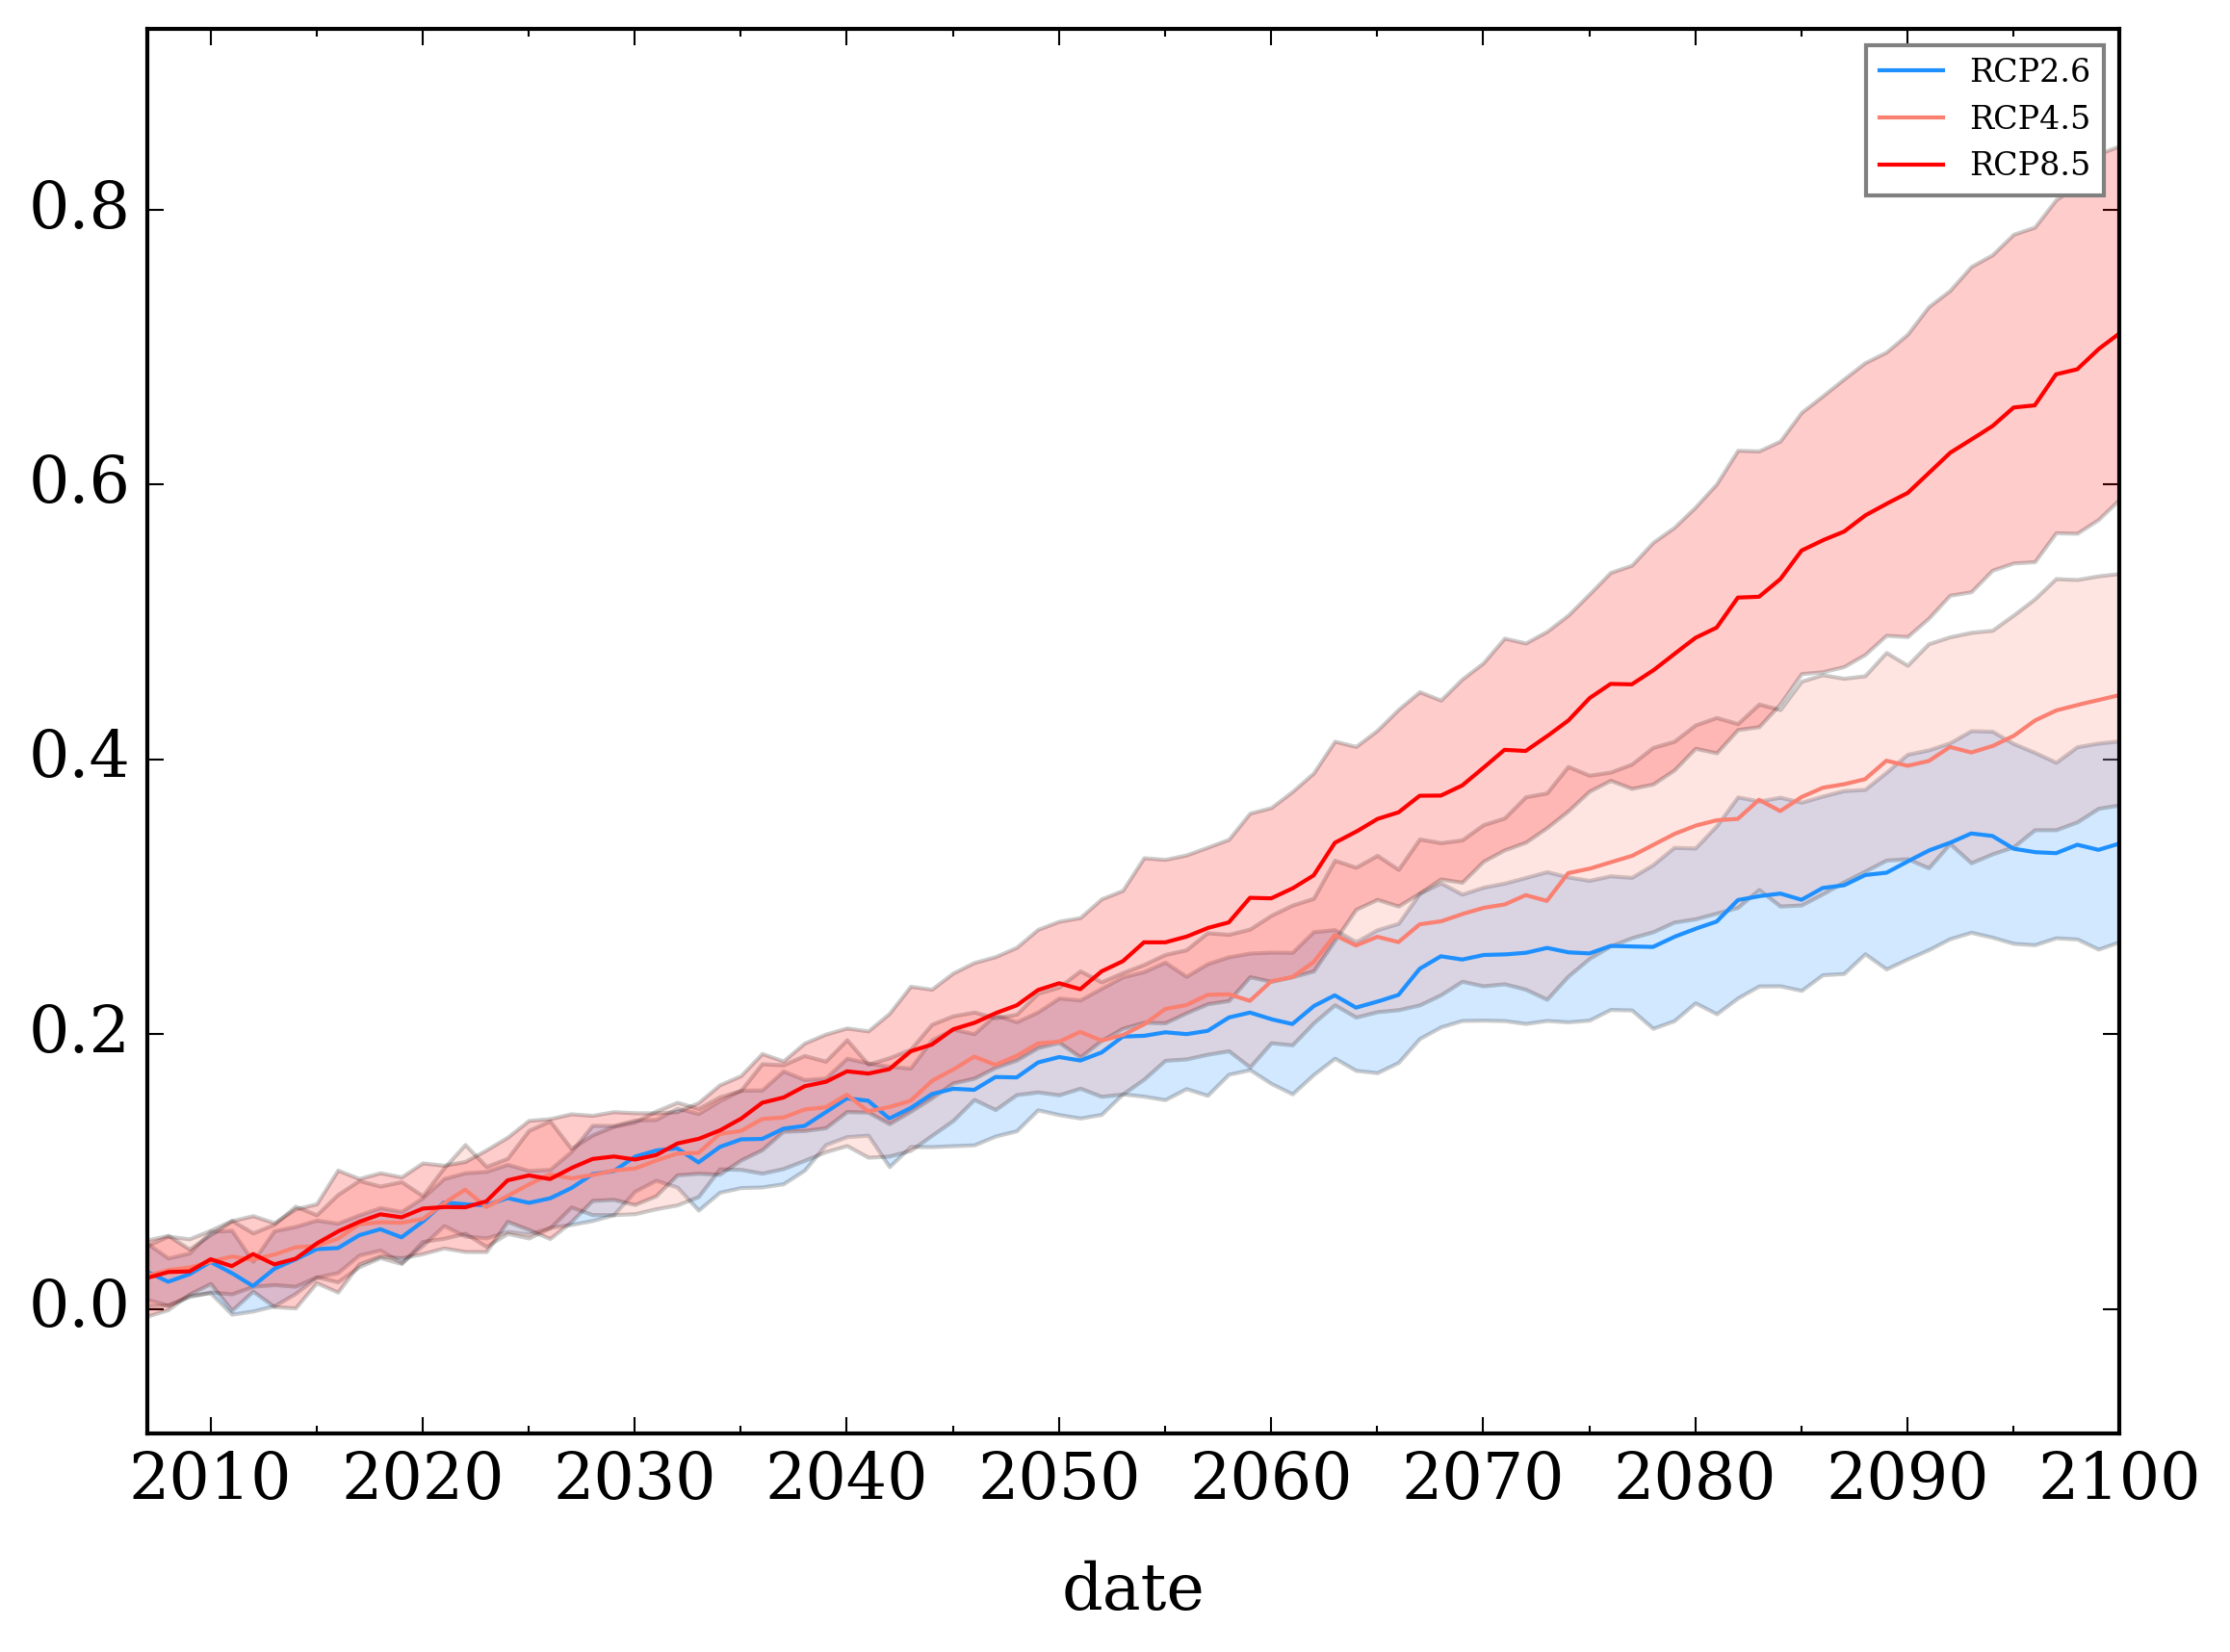

In [17]:
BV.oceanic.display_data('RSL')

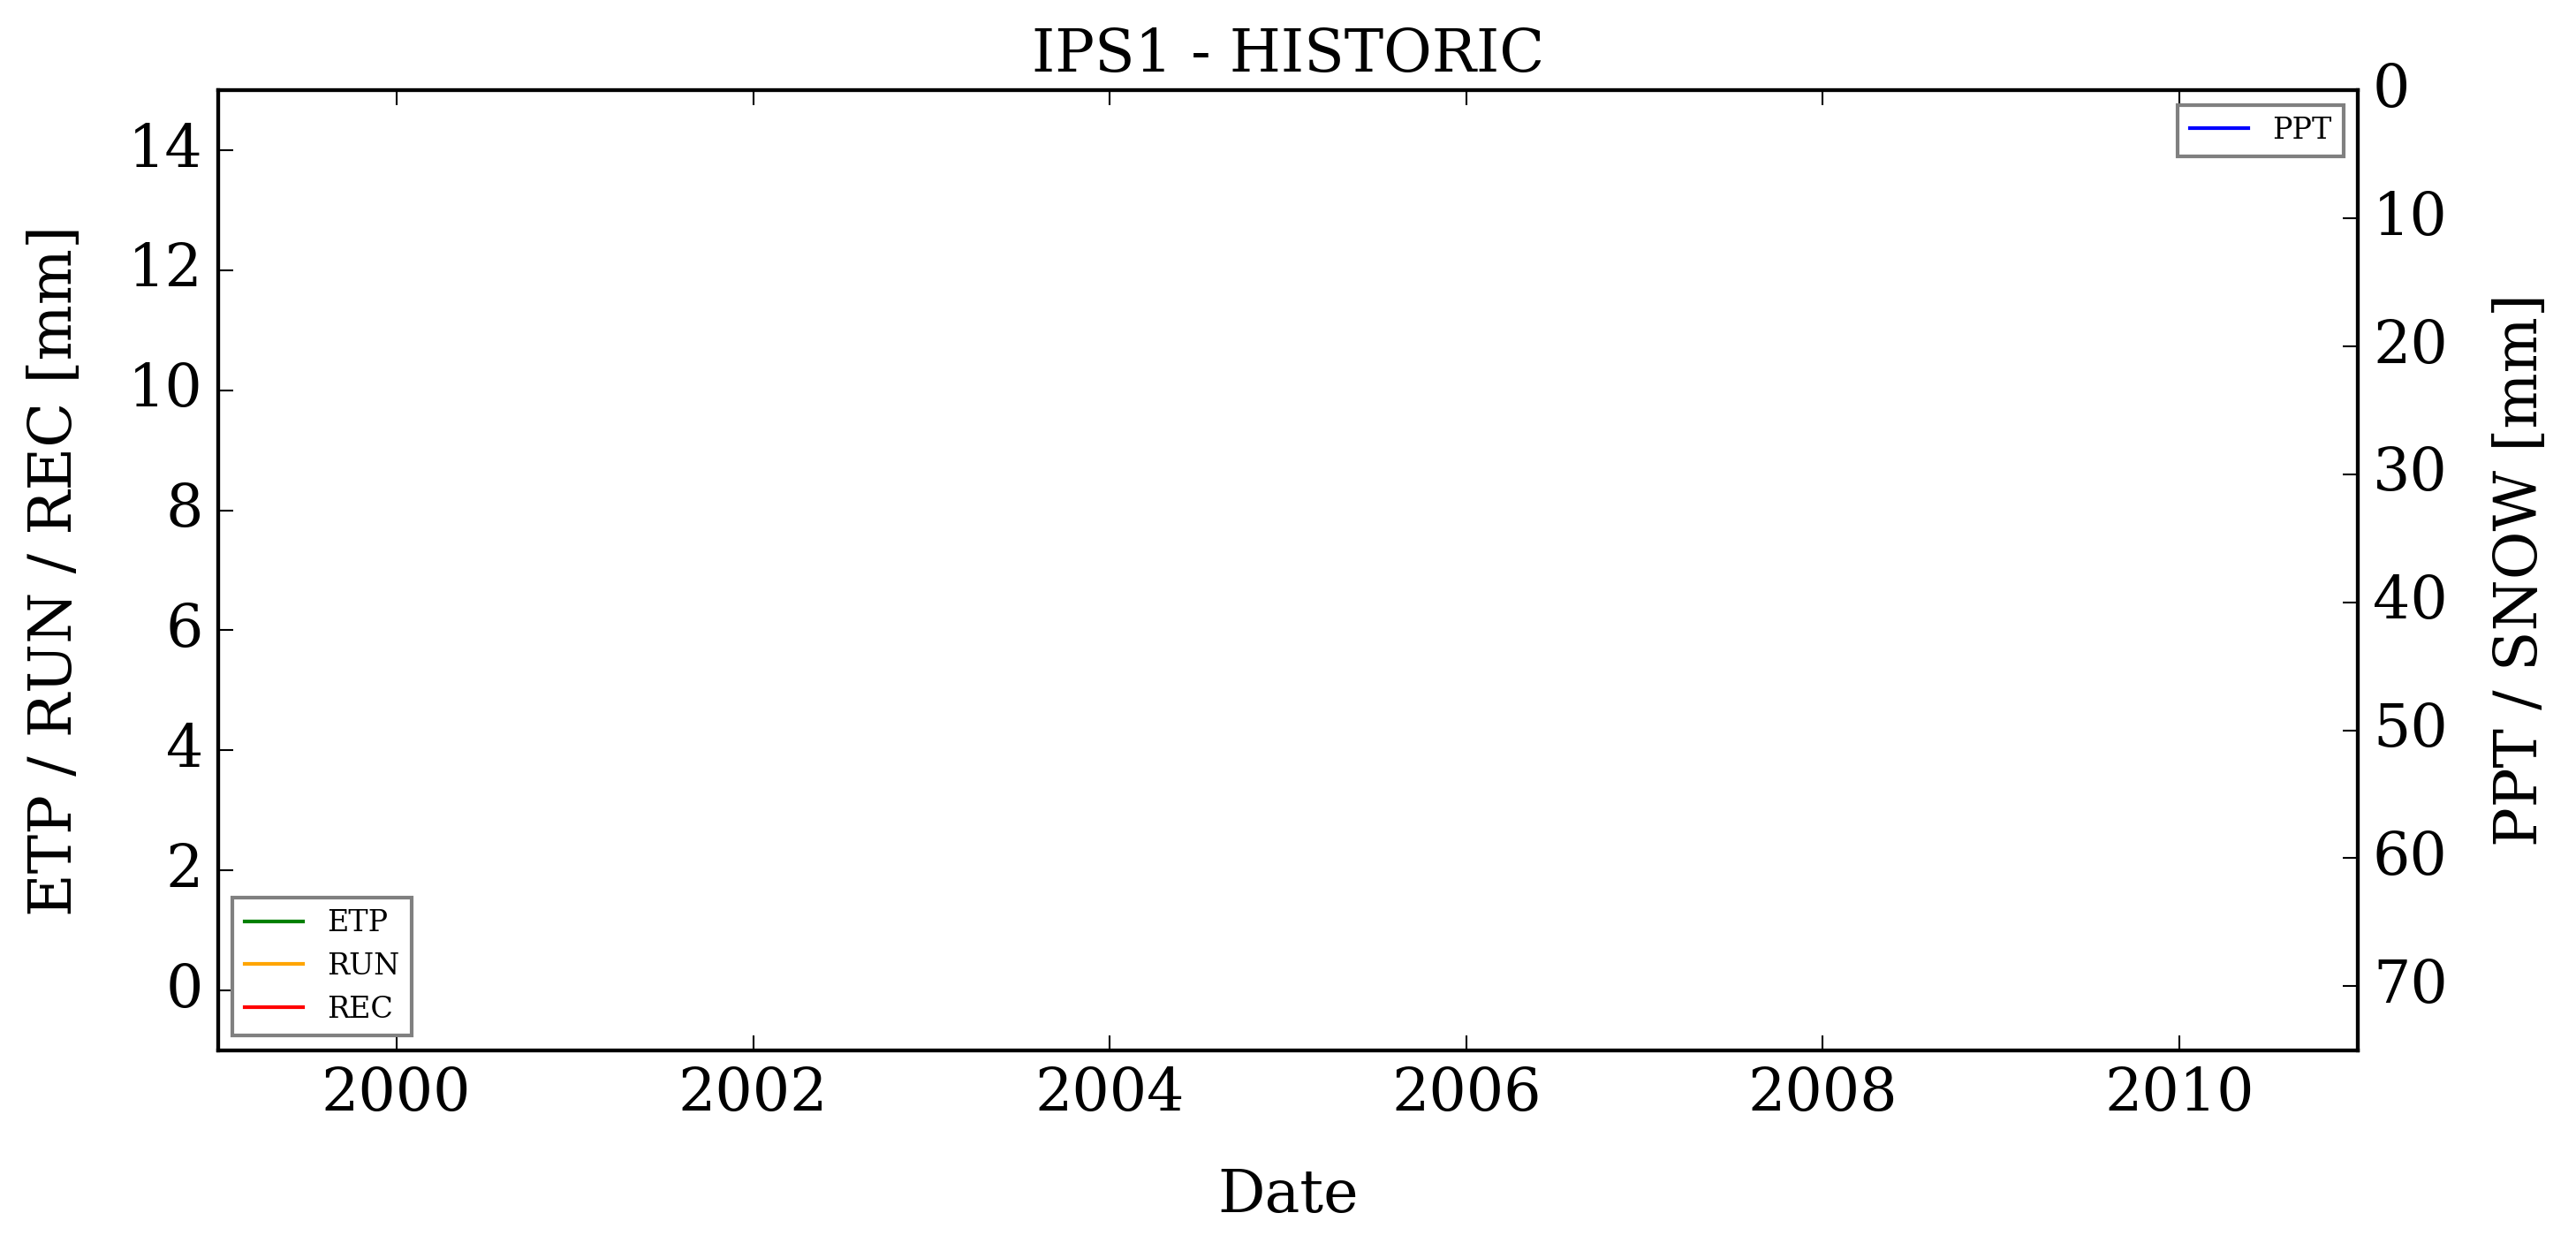

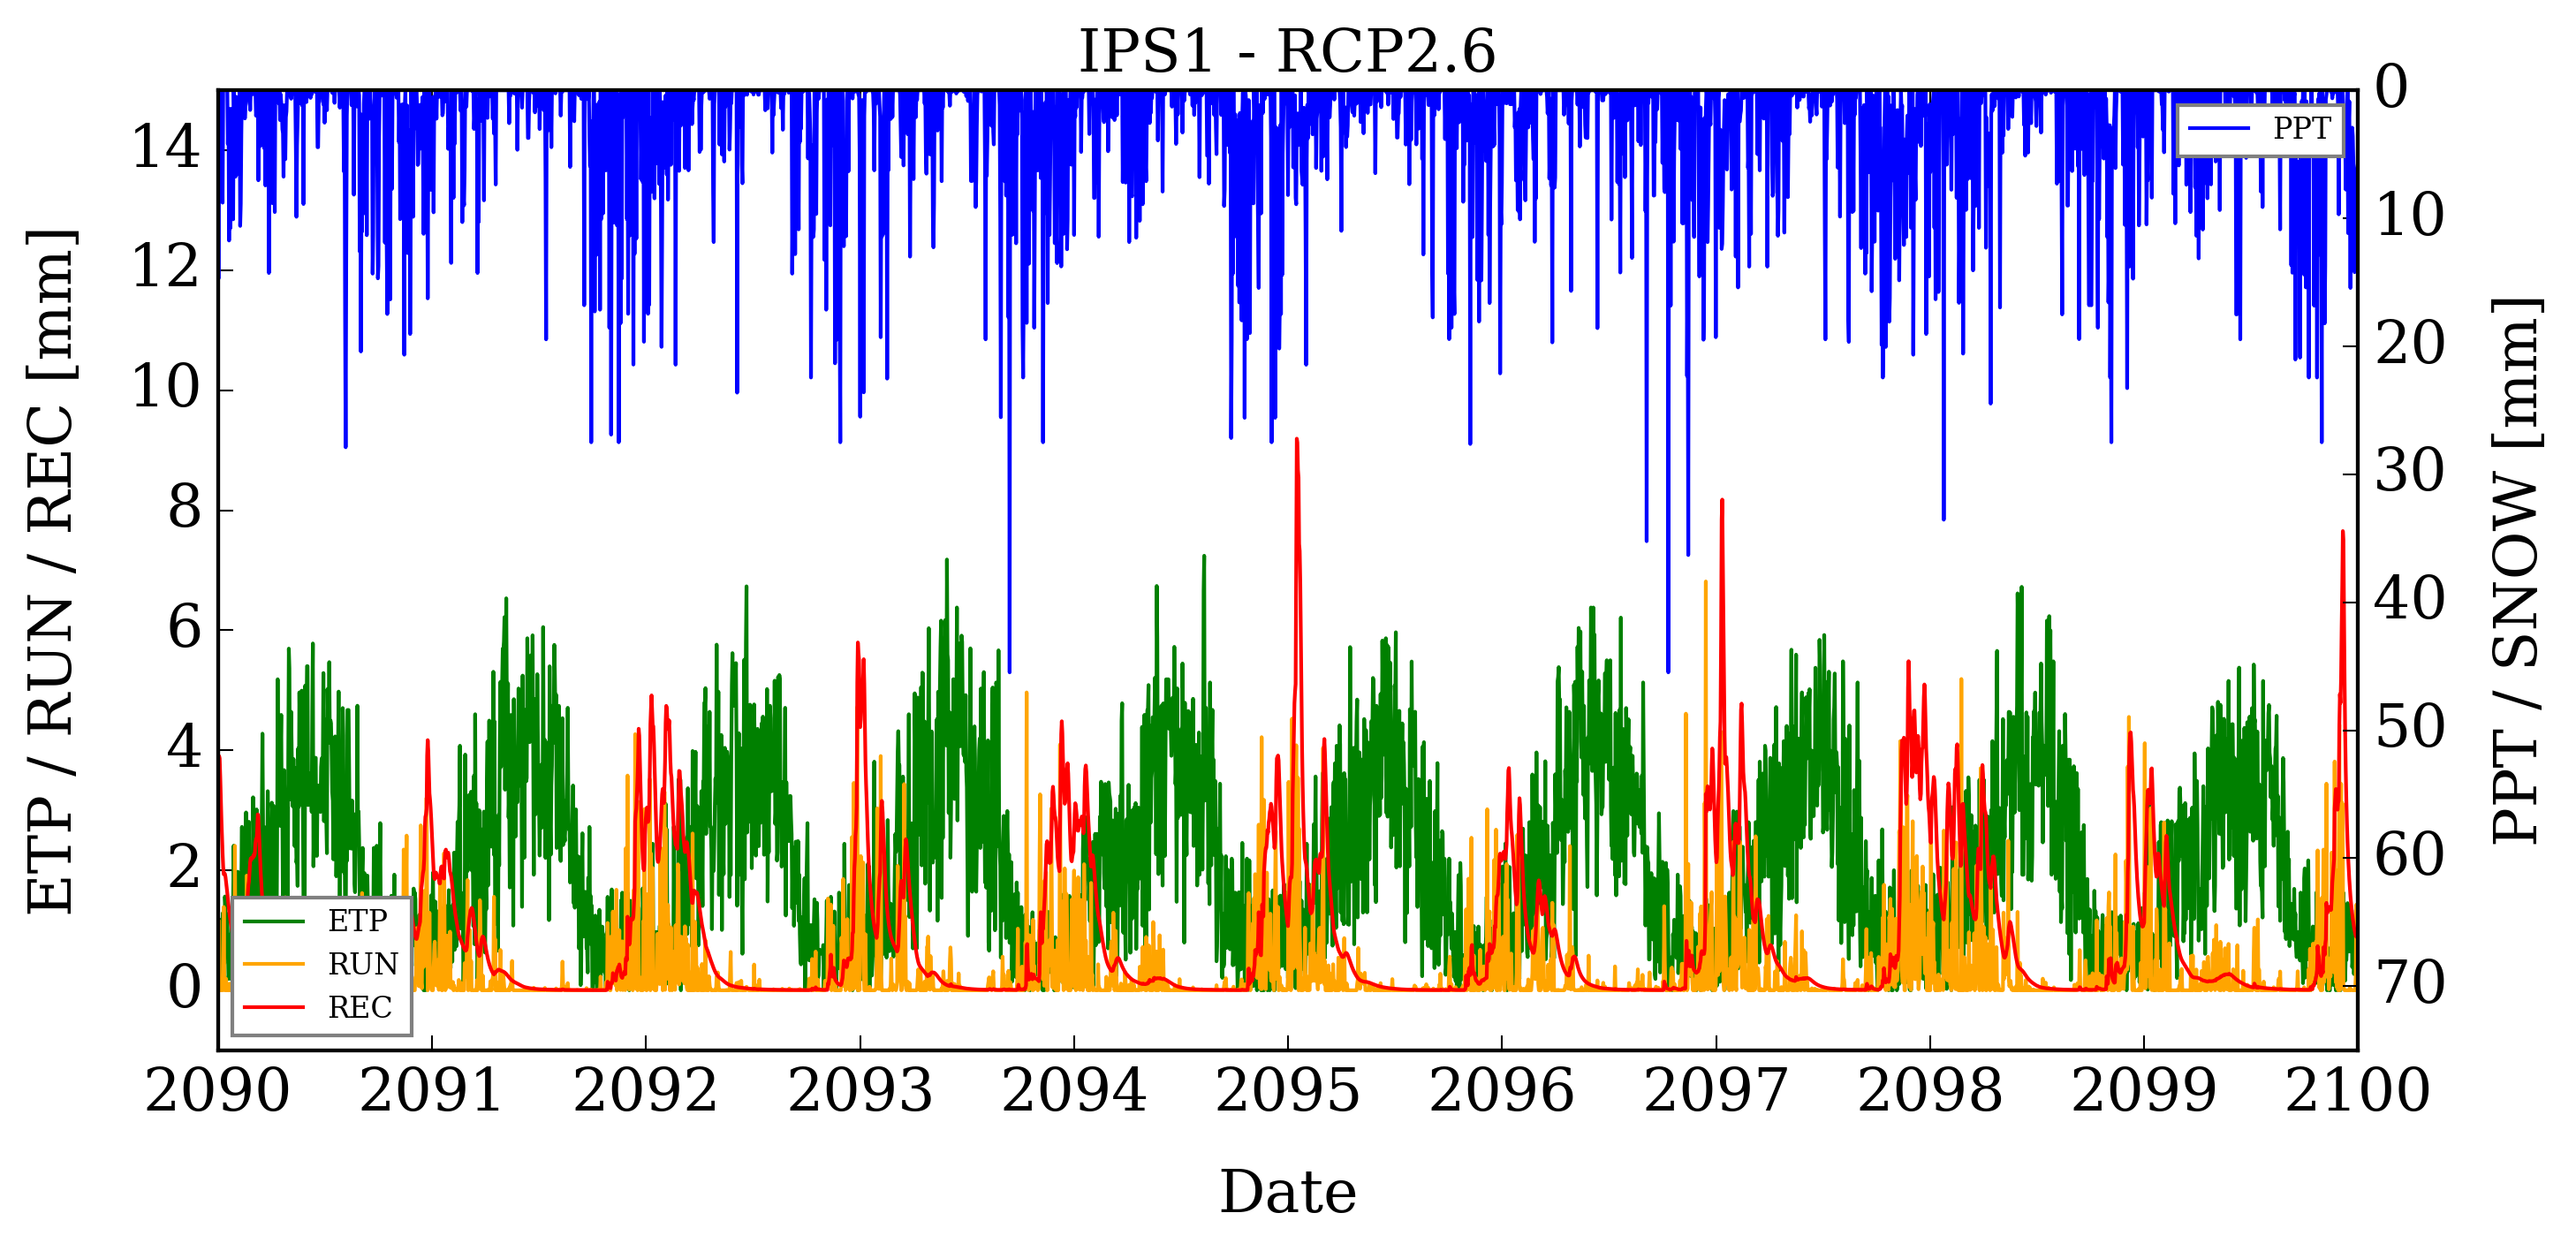

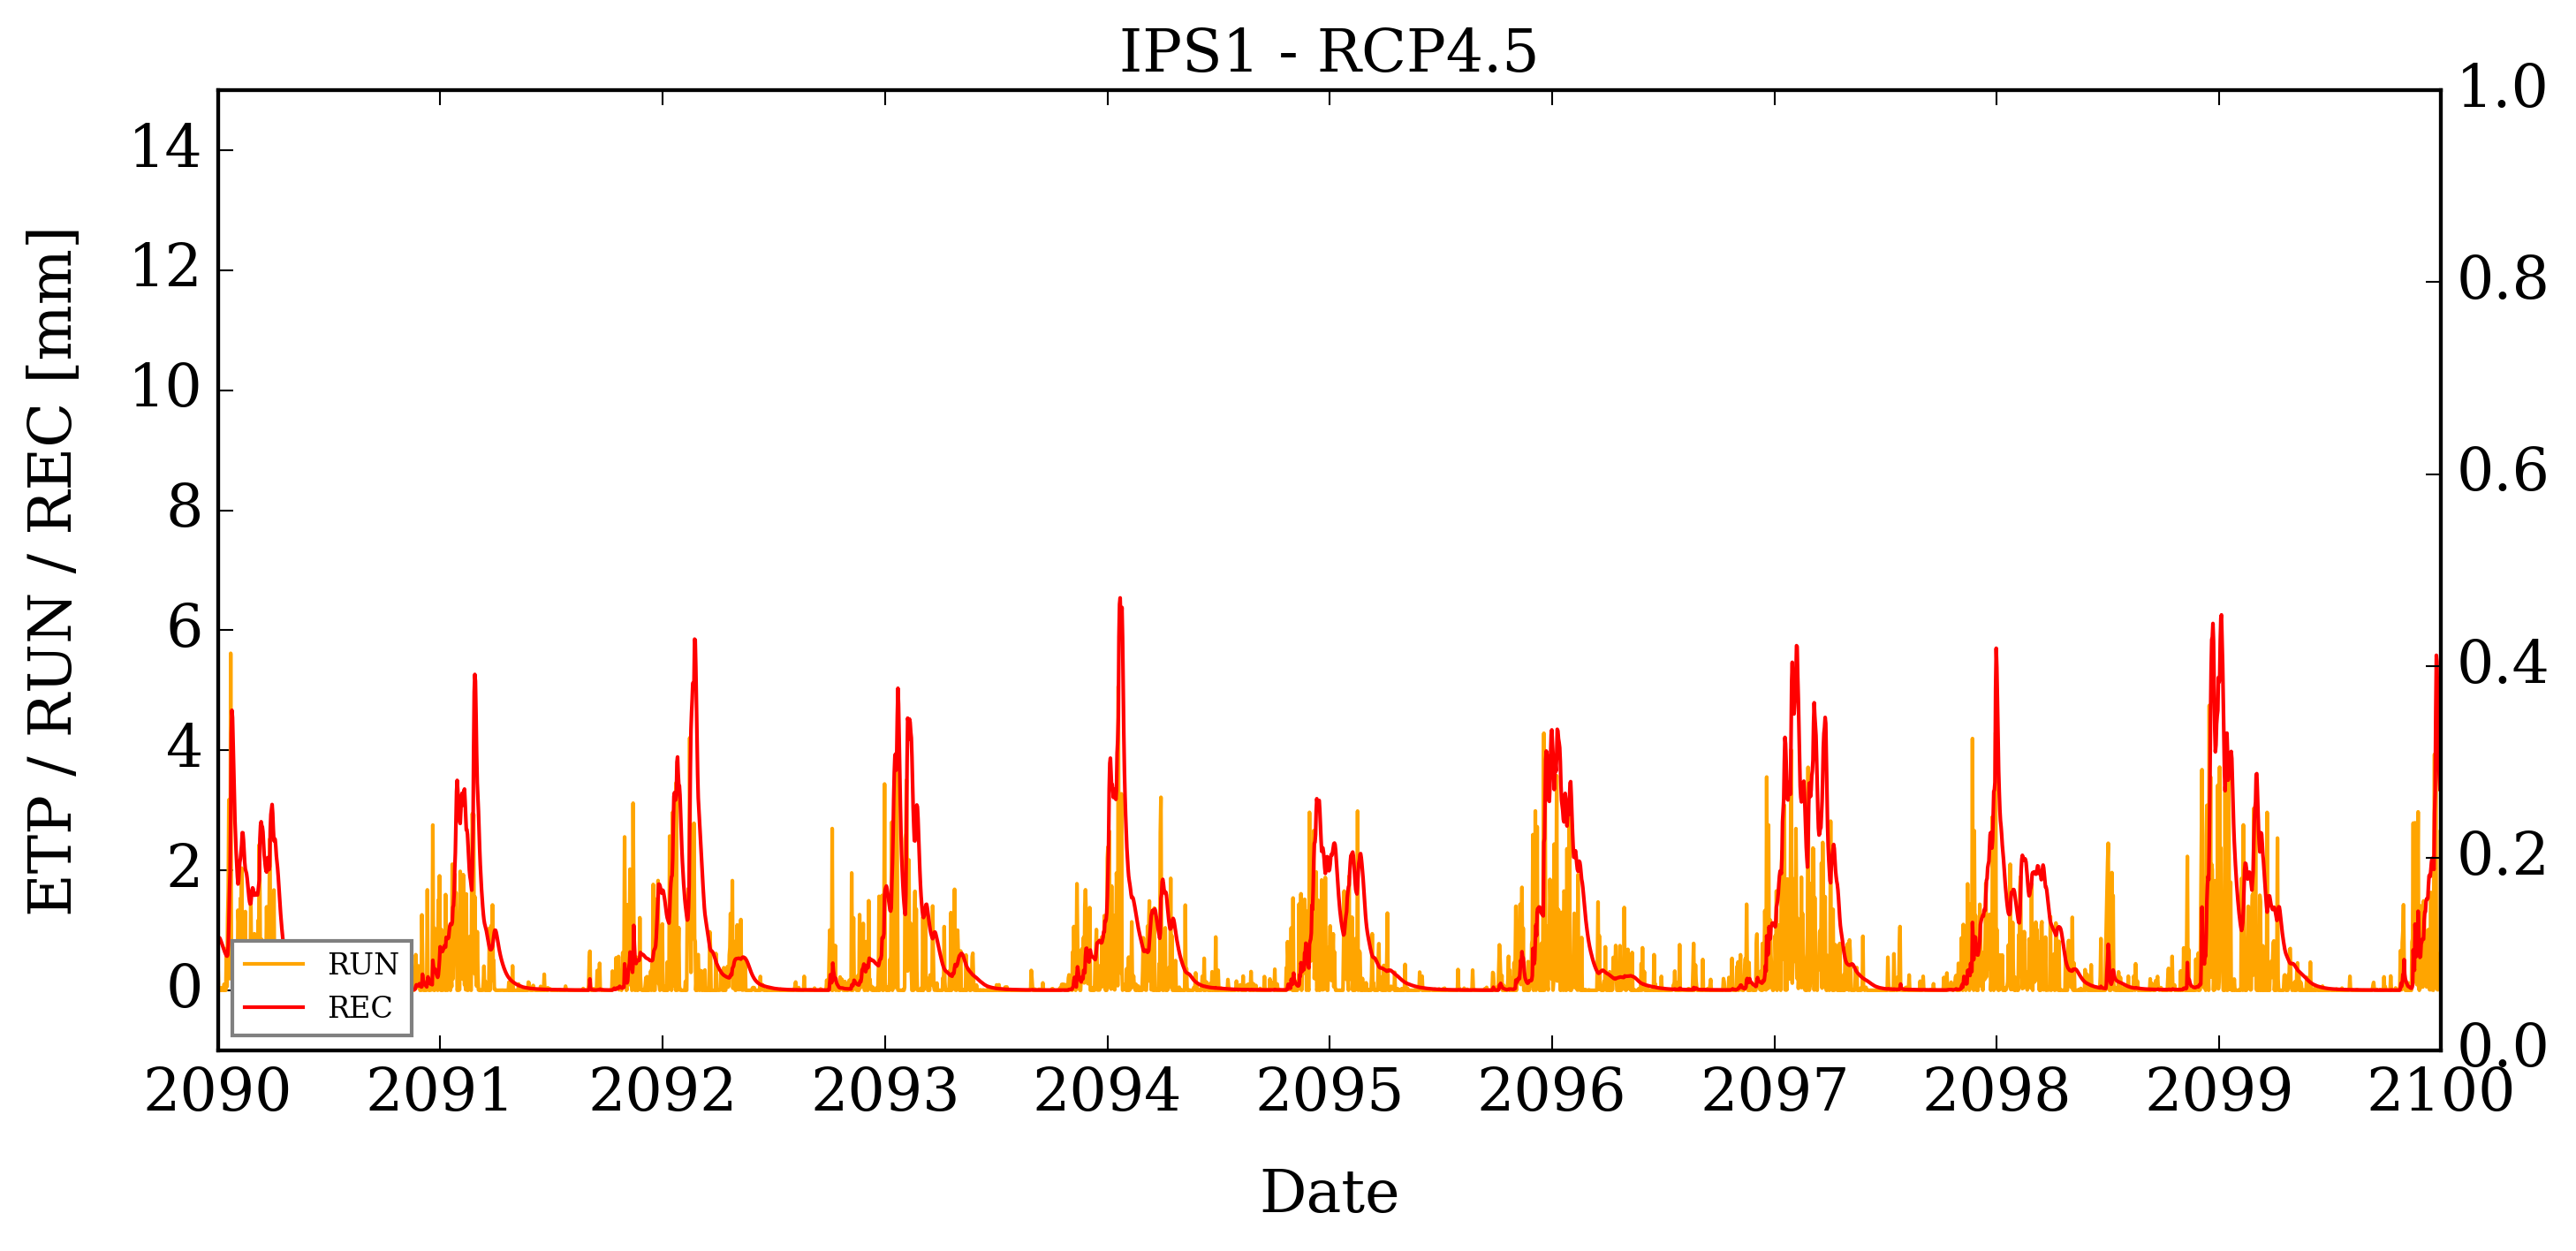

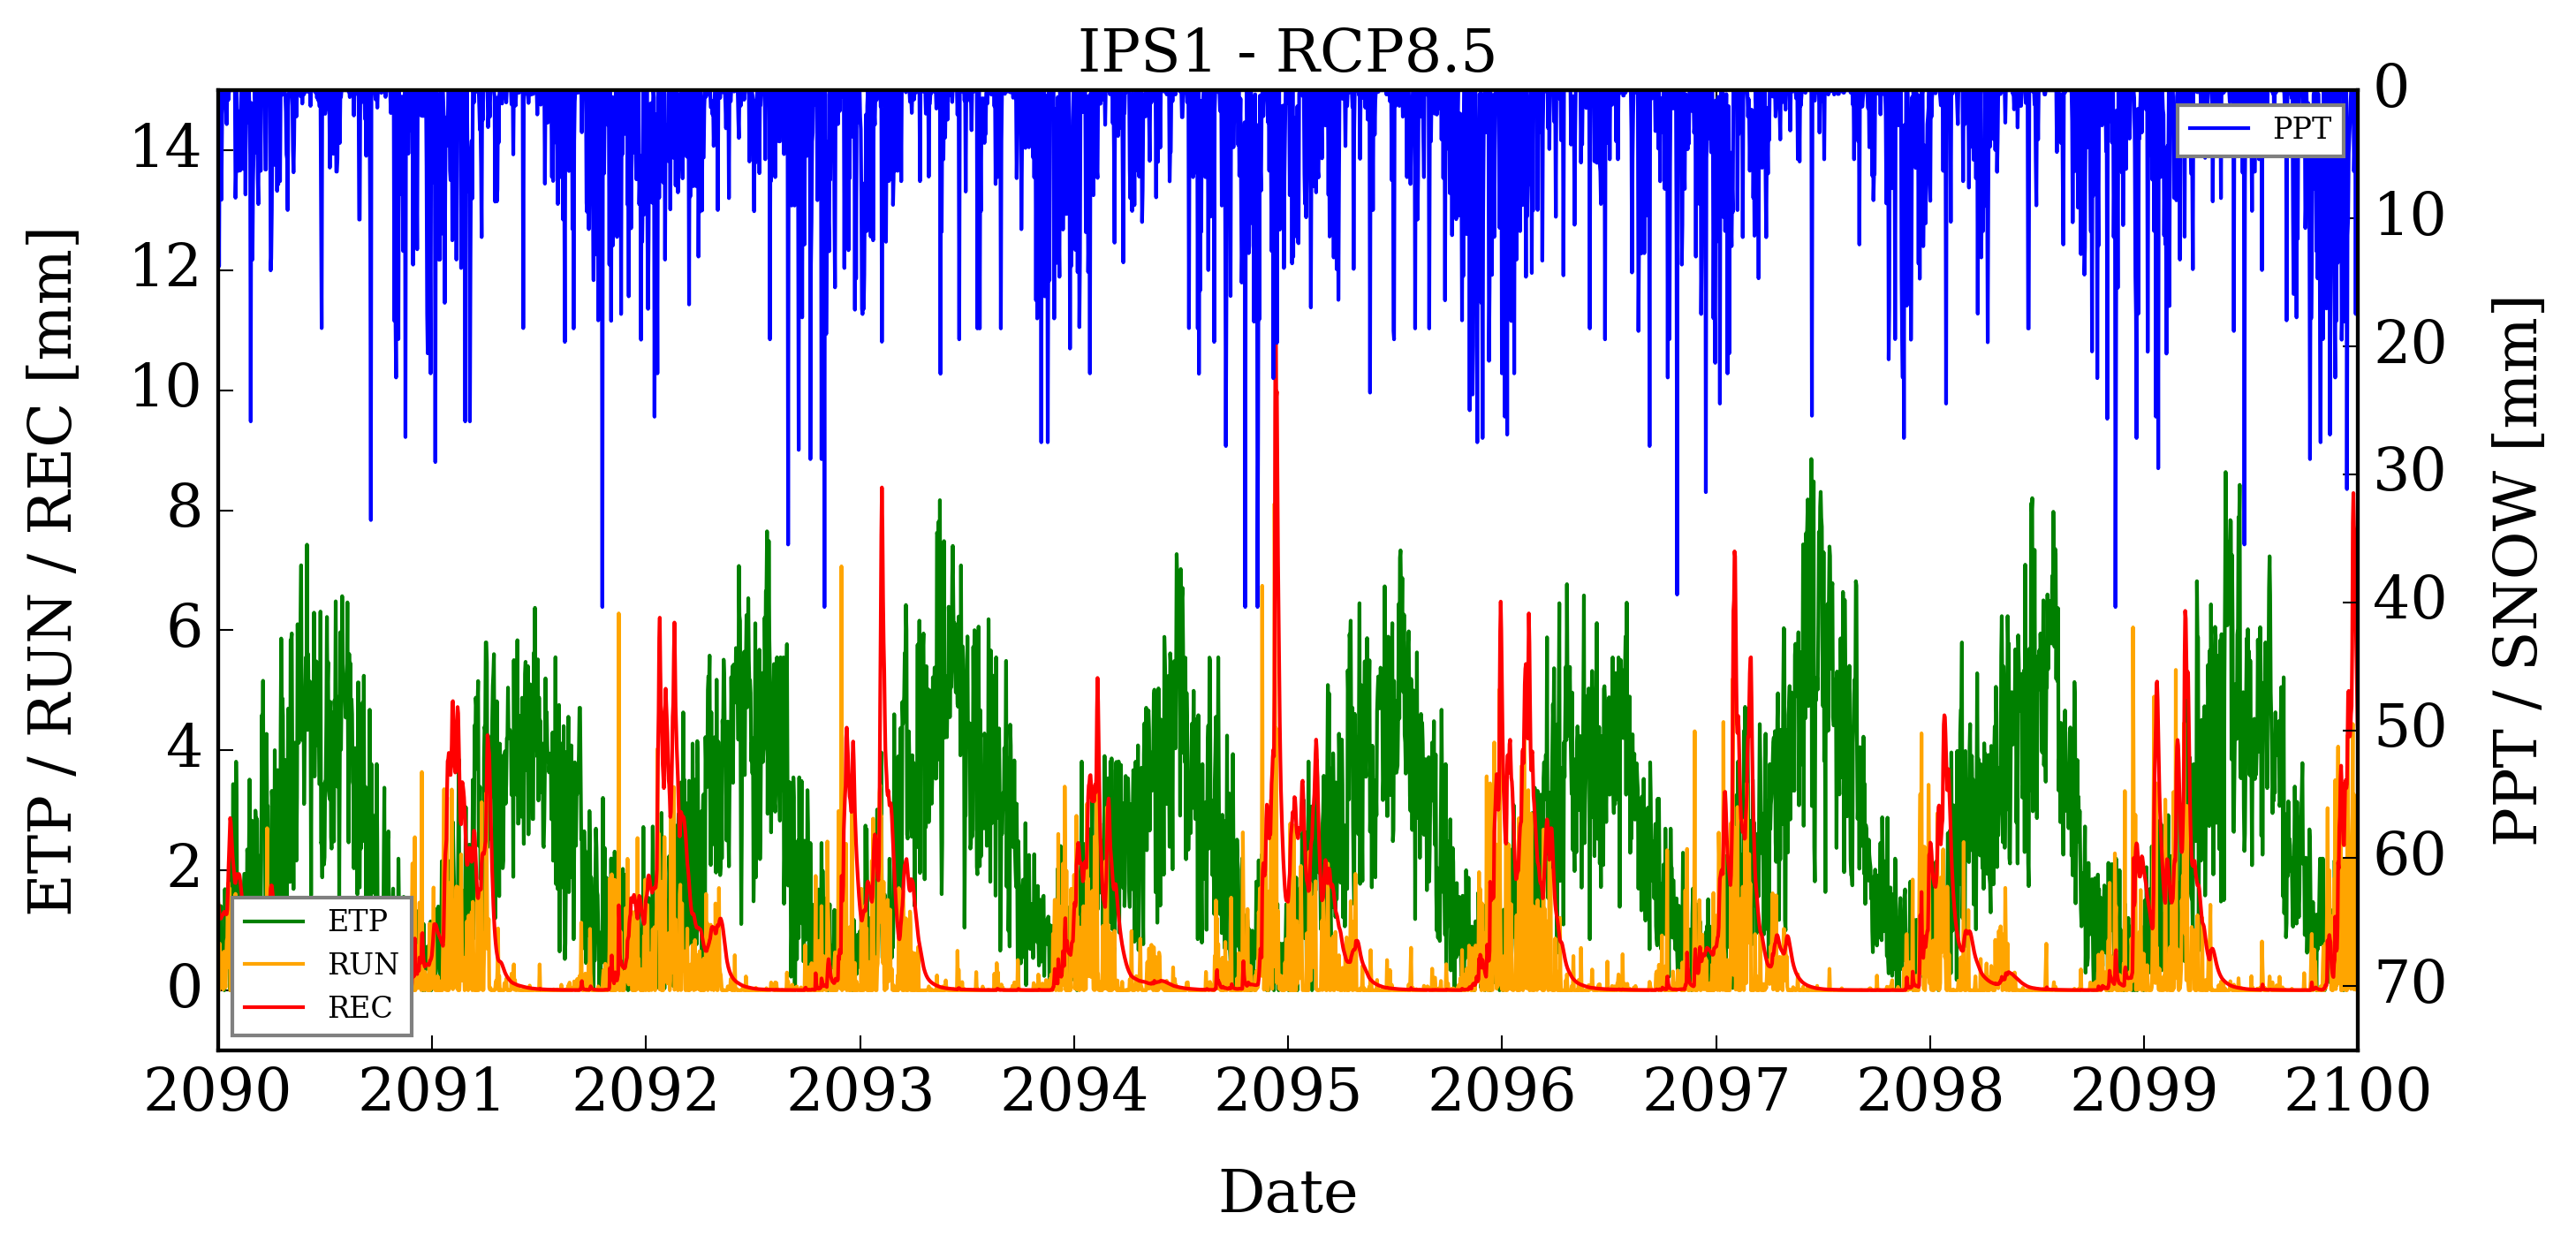

In [18]:
BV.climatic.display_all_variables('IPS1',start='2090', end='2100')

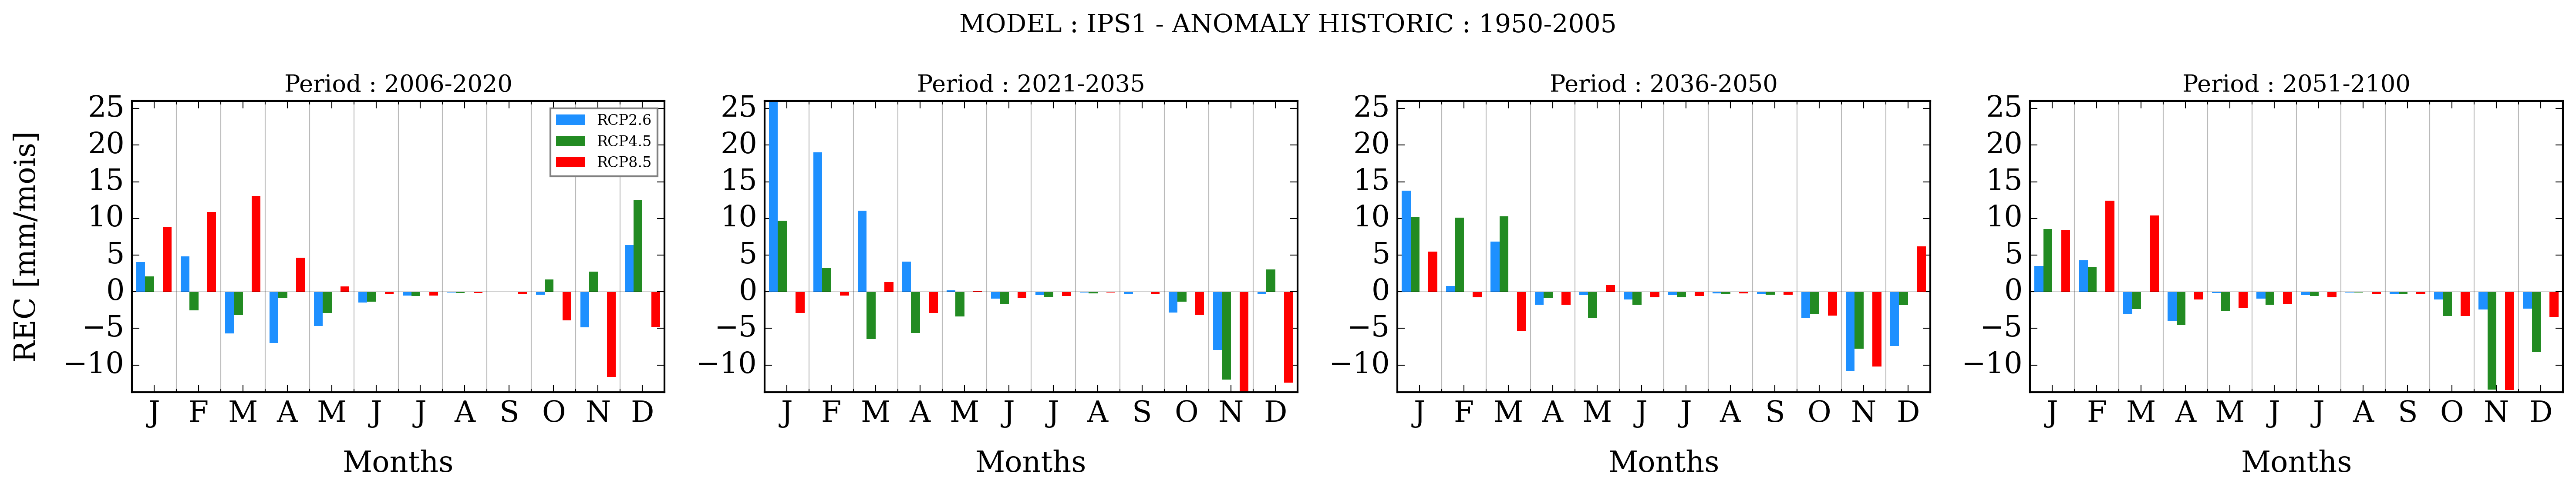

In [19]:
BV.climatic.display_anomaly('IPS1','REC')

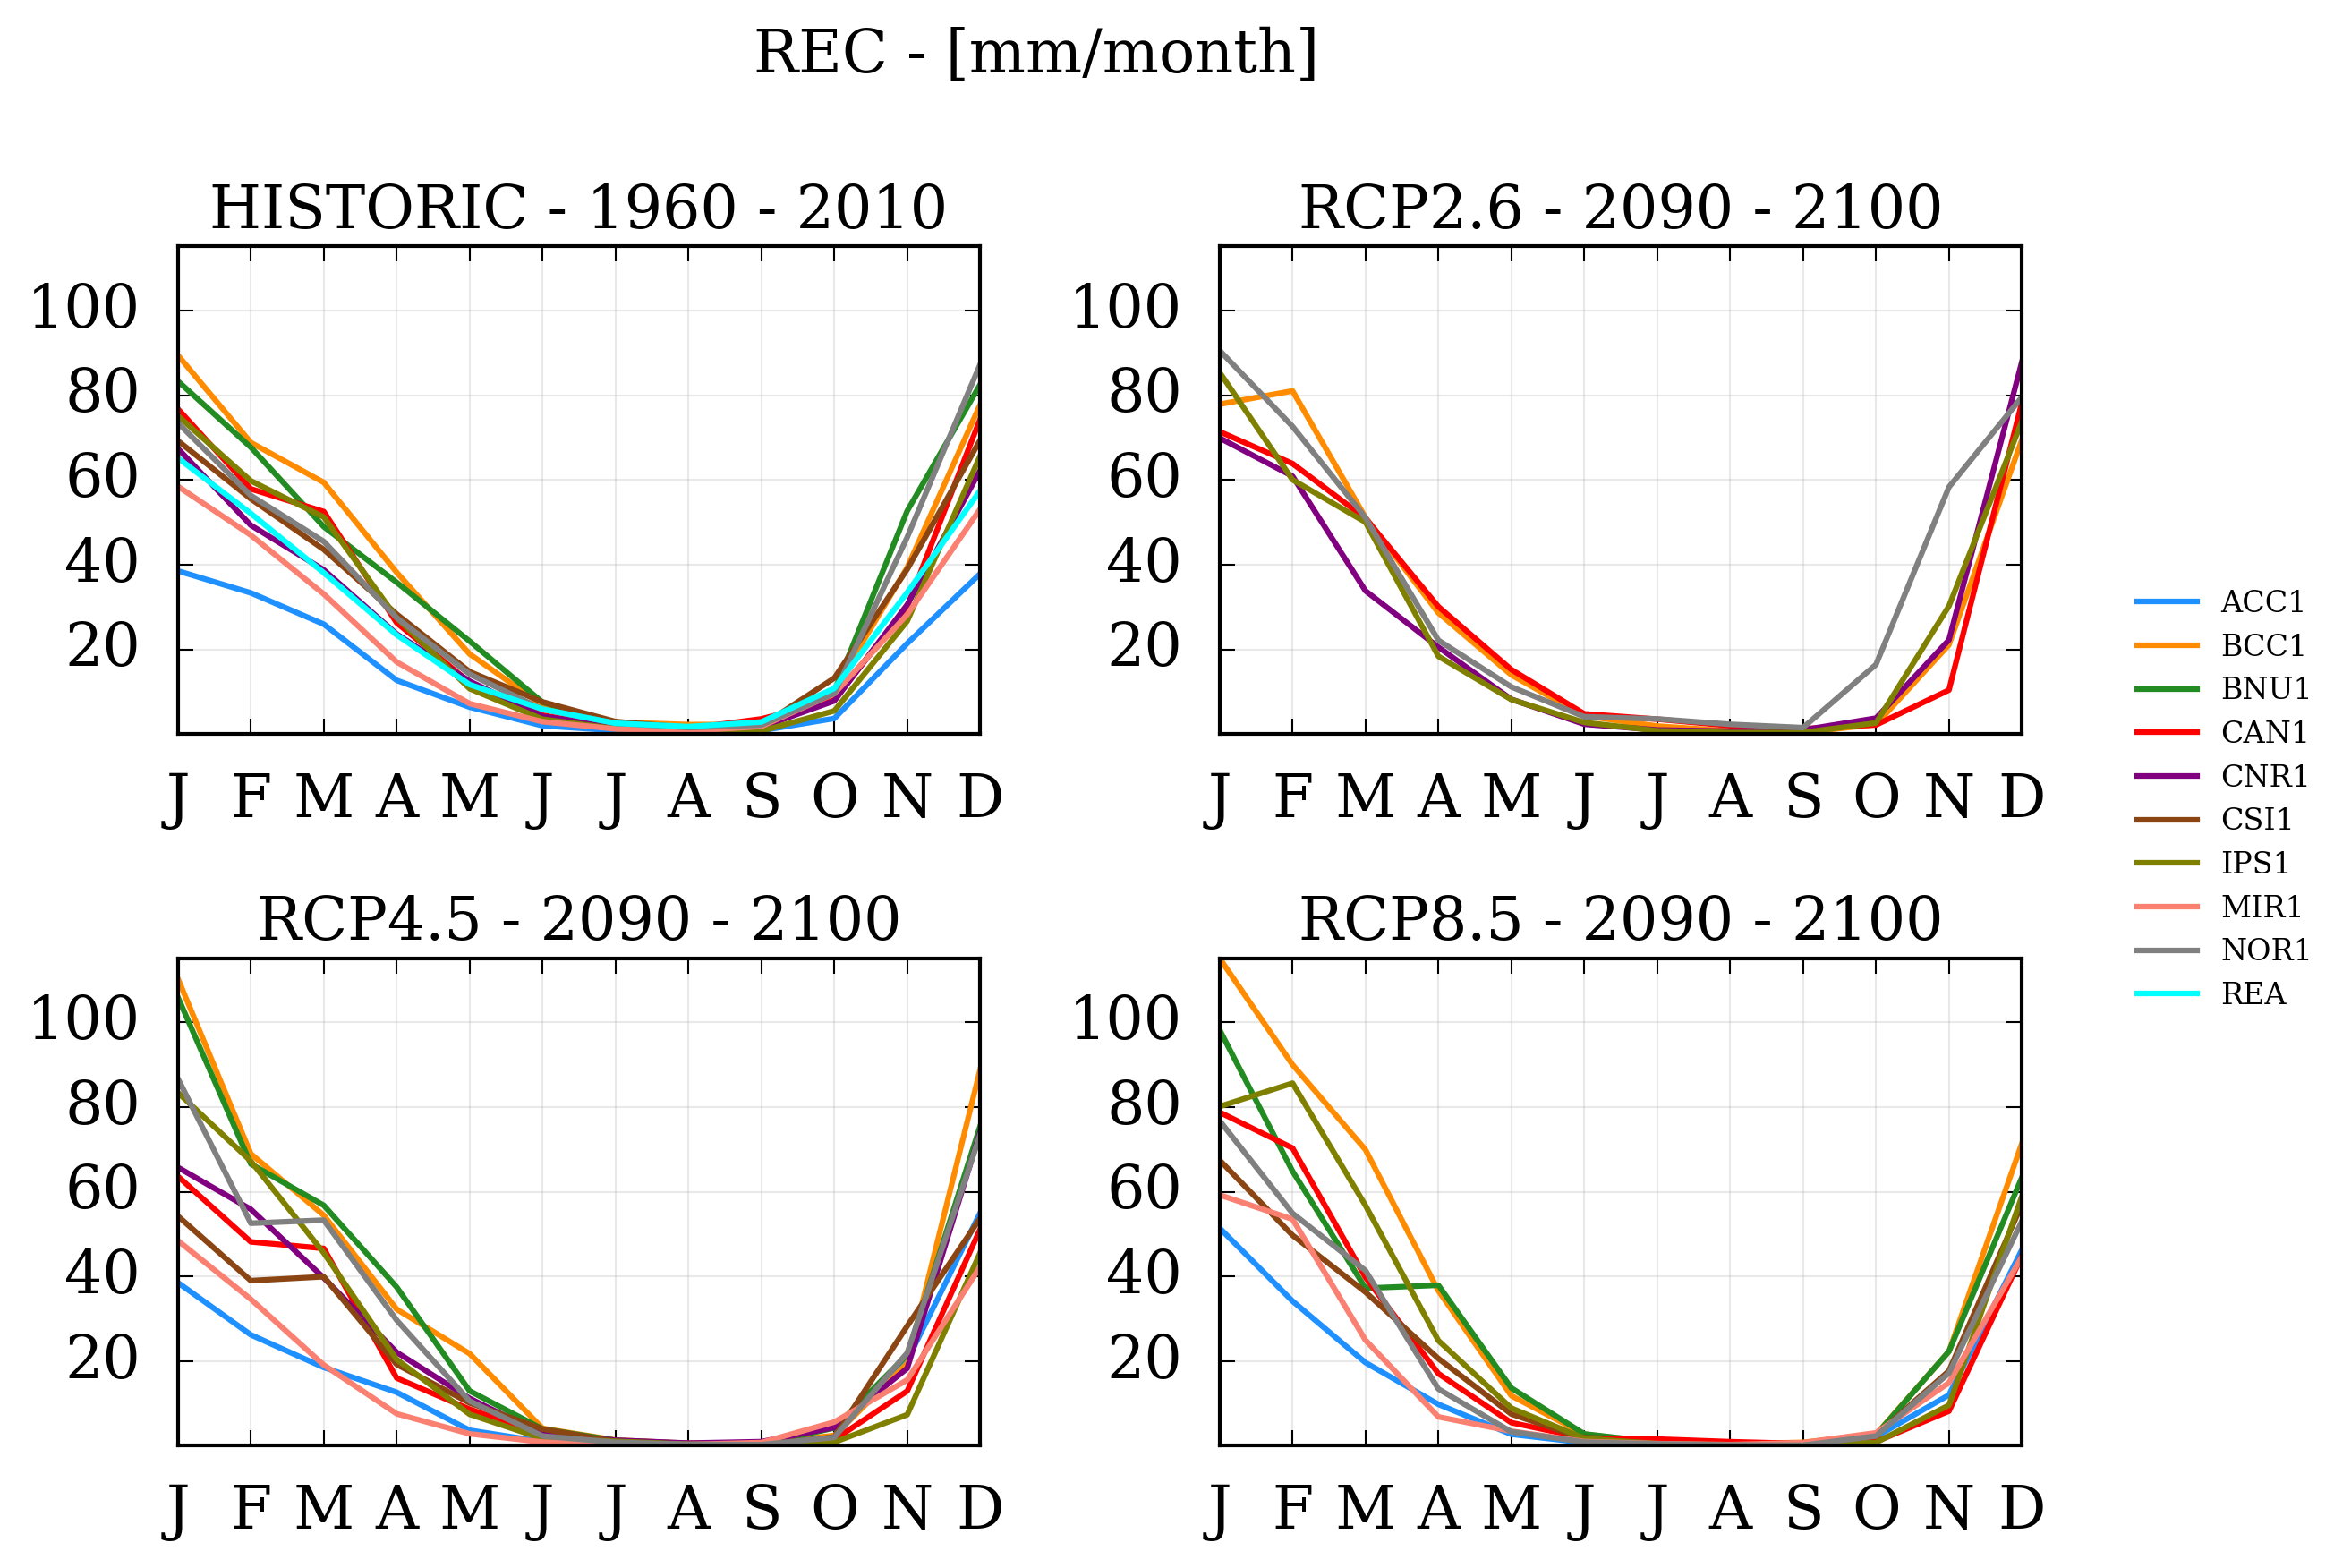

In [20]:
BV.climatic.display_intermensual_scenarios('REC')

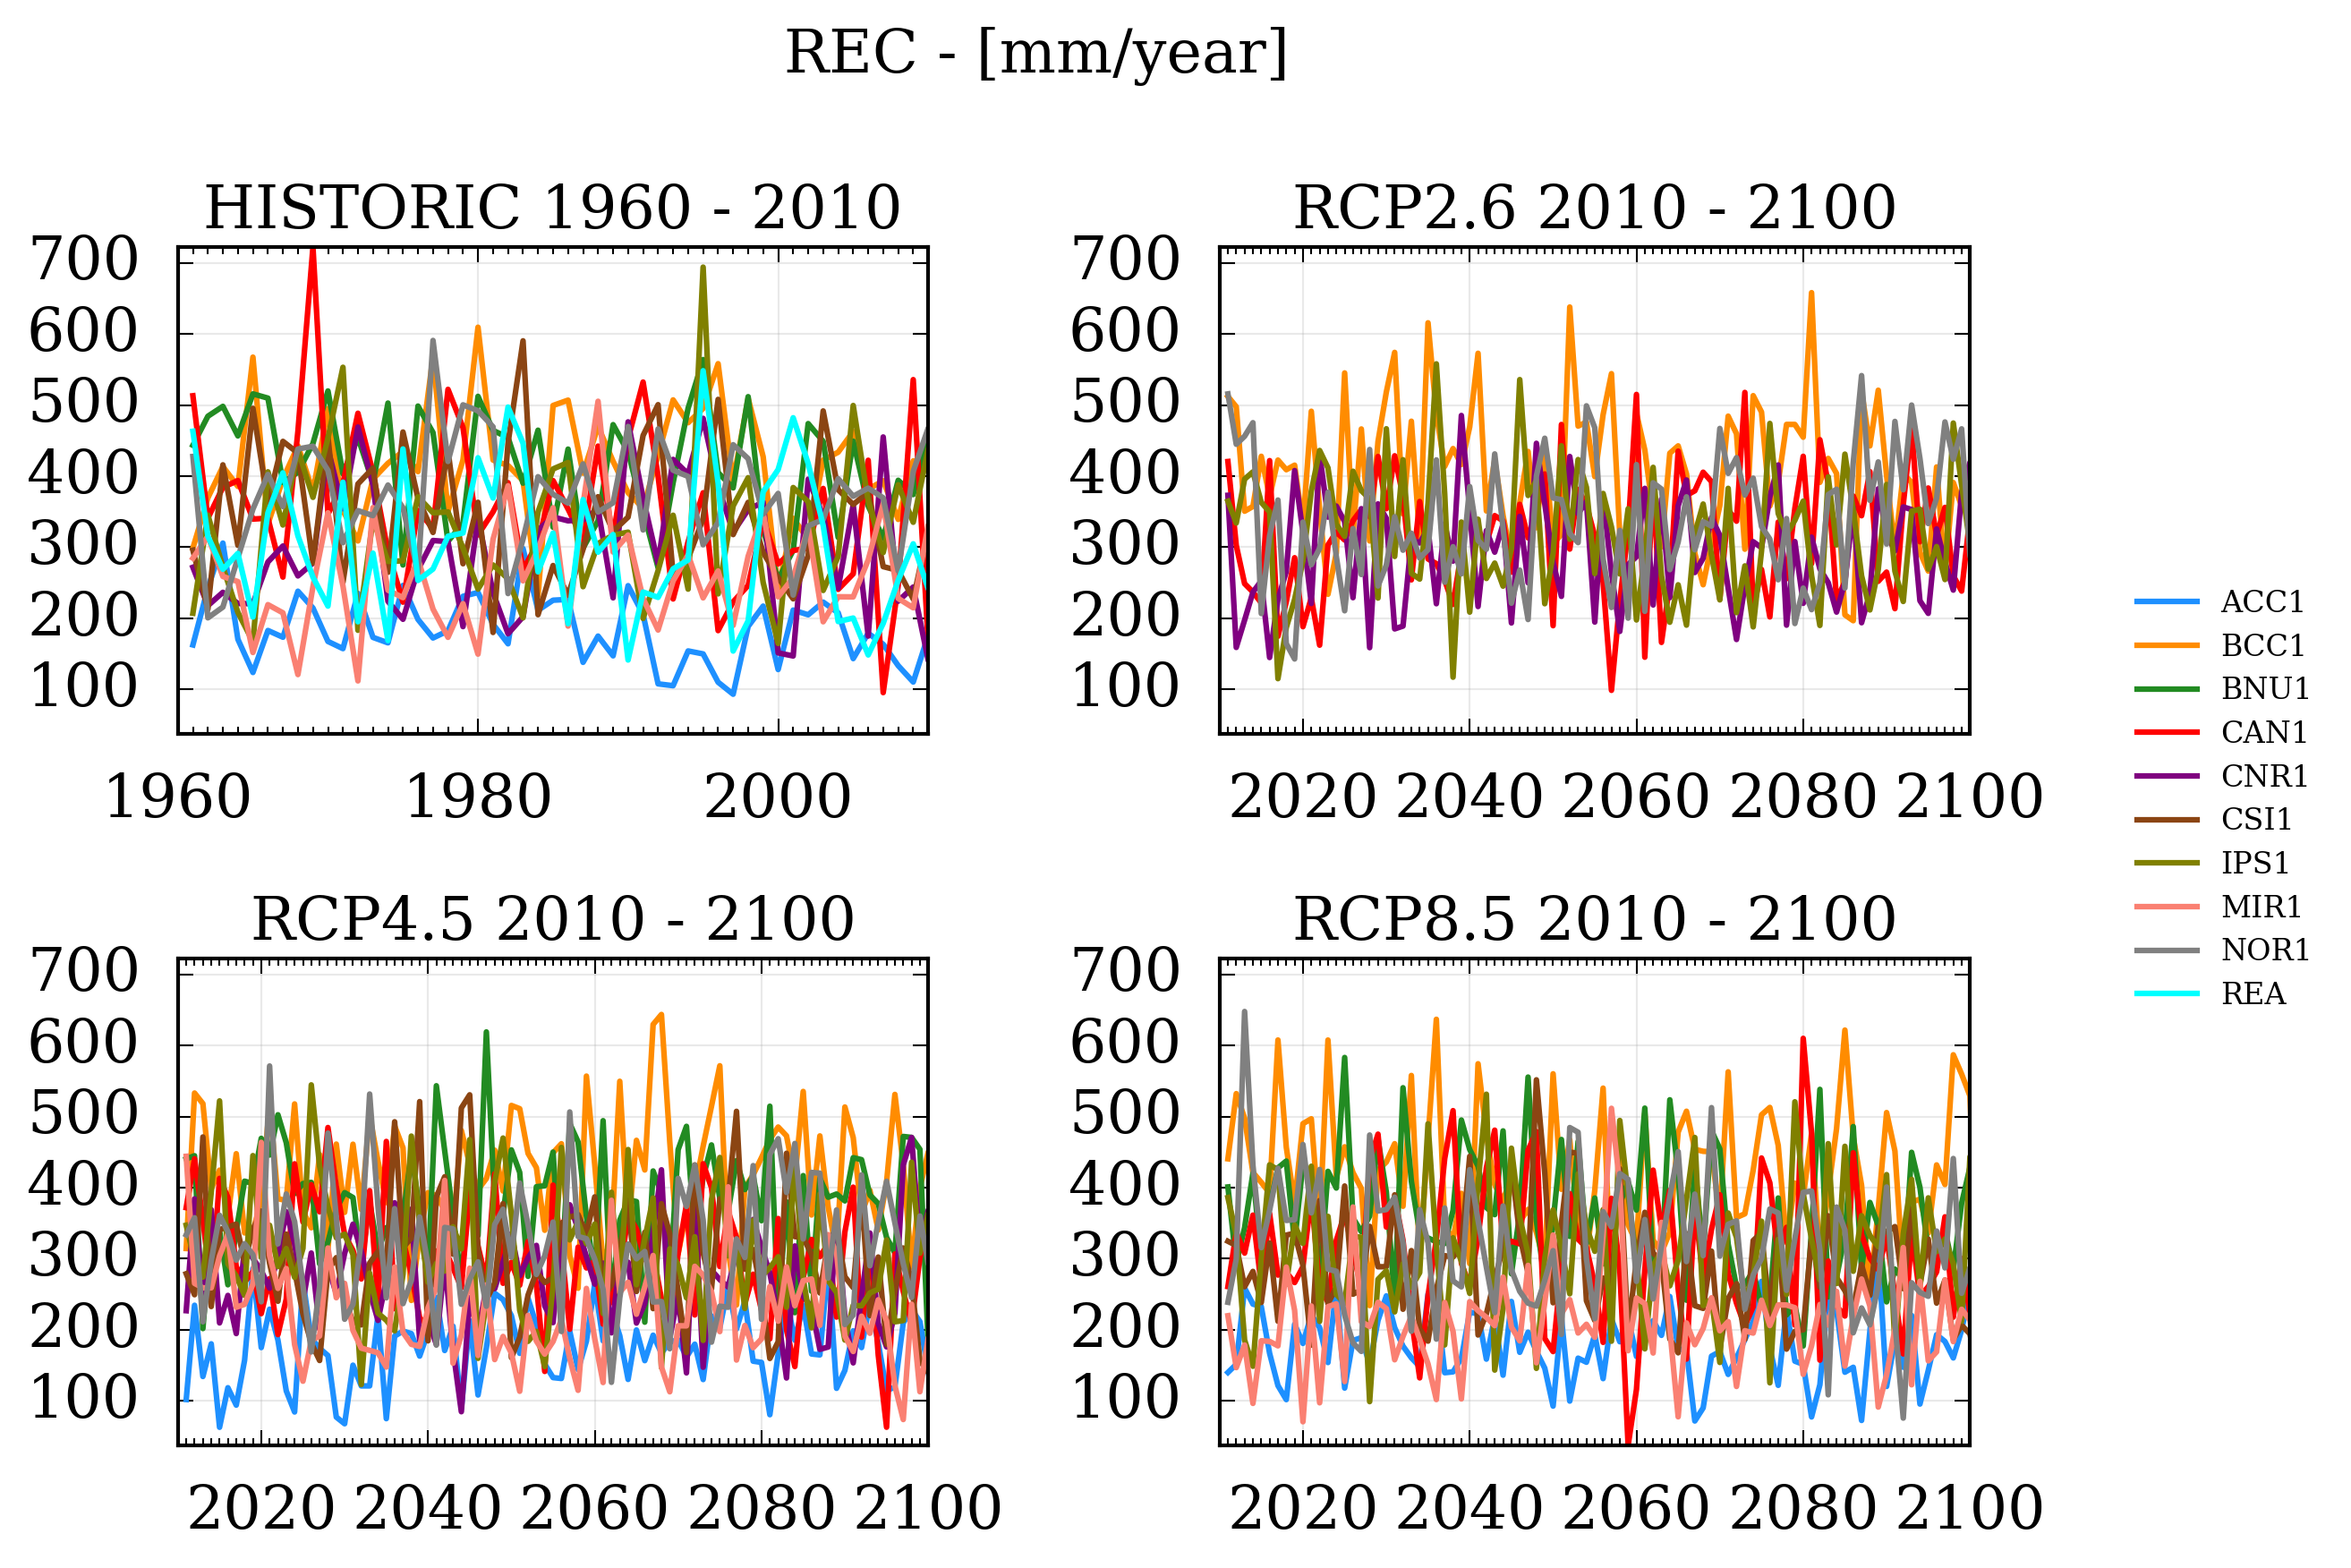

In [21]:
BV.climatic.display_annual_scenarios('REC')

In [22]:
import sys
sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
import climatic
shp_bretagne = 'C:/Users/alexa/Dropbox/PhD/4 - Data/fr/Bretagne.shp'
shp_normandie = 'C:/Users/alexa/Dropbox/PhD/4 - Data/fr/Normandie2.shp'
surfex_path = 'D:/SURFEX/DATA/COREC_h5'
out_path = 'D:/SURFEX/'
c = climatic.extract(out_path, surfex_path, shp_normandie)


FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: 'D:/'

In [23]:
import pickle

filename = 'C:/Users/alexa/Dropbox/HydroModPy/container.pkl'

class Container(object):
    def __init__(self, name):
        self.name = name
        self.widgets = []

class Widget(object):
    def __init__(self, name):
        self.name = name

c = Container('My Container')
w = Widget('My Widget')

w

c.widgets.append(w)

data = open(filename, 'wb')
pickle.dump(c, data)
data.close()

In [ ]:
dir(w)

In [ ]:
w.__class__ = 'test'

In [ ]:
c.widgets

In [1]:
geo = [1,2,3]
import params
a = params.Params(geo)

In [2]:
a.store

,names,geo_codes,types,units
0,K1,1,Hydraulic Conductivity,m/d
1,K2,2,Hydraulic Conductivity,m/d
2,K3,3,Hydraulic Conductivity,m/d
3,Phi1,1,Porosity,-
4,Phi2,2,Porosity,-
5,Phi3,3,Porosity,-
6,E1,1,Thickness,m
7,E2,2,Thickness,m
8,E3,3,Thickness,m
